# **Análisis exploratorio de datos**

### *Default clients*

0. Importación de librerias 

In [4]:
%pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


1. Carga de datos 

In [5]:
ruta_archivo = "../data/raw/Default_Clientes.csv"
df = pd.read_csv(ruta_archivo, sep=";")

print("\n--- Estructura inicial del Dataset ---")
print(df.info())
print("\n", df.describe())


--- Estructura inicial del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-

2. Limpieza e imputación 

In [6]:
cols_numericas = df.select_dtypes(include=[np.number]).columns
cols_texto = df.select_dtypes(include=['object']).columns

# Imputación: mediana para numéricas, moda para categóricas
df[cols_numericas] = df[cols_numericas].fillna(df[cols_numericas].median())

if not cols_texto.empty:
    for col in cols_texto:
        df[col] = df[col].fillna(df[col].mode()[0])

# Convertir variables que conceptualmente son categóricas al tipo 'category'
cols_categoricas = ["SEX", "EDUCATION", "MARRIAGE", "PAY_0", "PAY_2", "PAY_3", 
                    "PAY_4", "PAY_5", "PAY_6", "Default"]

for col in cols_categoricas:
    if col in df.columns:
        df[col] = df[col].astype('category')
    else:
        print(f"Advertencia: columna '{col}' no encontrada")

print("\nColumnas categóricas convertidas exitosamente")
print(f"Columnas categóricas: {df.select_dtypes(include=['category']).columns.tolist()}")


Columnas categóricas convertidas exitosamente
Columnas categóricas: ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'Default']


3. ESTADÍSTICAS DESCRIPTIVAS POST-LIMPIEZA

In [7]:
print("\n--- Resumen de Datos Limpios ---")
print(df.describe(include='all'))


--- Resumen de Datos Limpios ---
                  ID       LIMIT_BAL      SEX  EDUCATION  MARRIAGE  \
count   30000.000000    30000.000000  30000.0    30000.0   30000.0   
unique           NaN             NaN      2.0        7.0       4.0   
top              NaN             NaN      2.0        2.0       2.0   
freq             NaN             NaN  18112.0    14030.0   15964.0   
mean    15000.500000   167484.322667      NaN        NaN       NaN   
std      8660.398374   129747.661567      NaN        NaN       NaN   
min         1.000000    10000.000000      NaN        NaN       NaN   
25%      7500.750000    50000.000000      NaN        NaN       NaN   
50%     15000.500000   140000.000000      NaN        NaN       NaN   
75%     22500.250000   240000.000000      NaN        NaN       NaN   
max     30000.000000  1000000.000000      NaN        NaN       NaN   

                 AGE    PAY_0    PAY_2    PAY_3    PAY_4  ...      BILL_AMT4  \
count   30000.000000  30000.0  30000.0  30000

4. VISUALIZACIÓN DE DATOS

C:\Users\maria\AppData\Local\Temp\ipykernel_12372\477940432.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Default', palette='Set2', edgecolor='black')


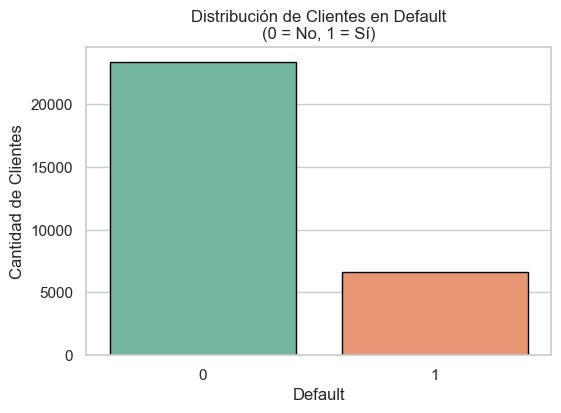

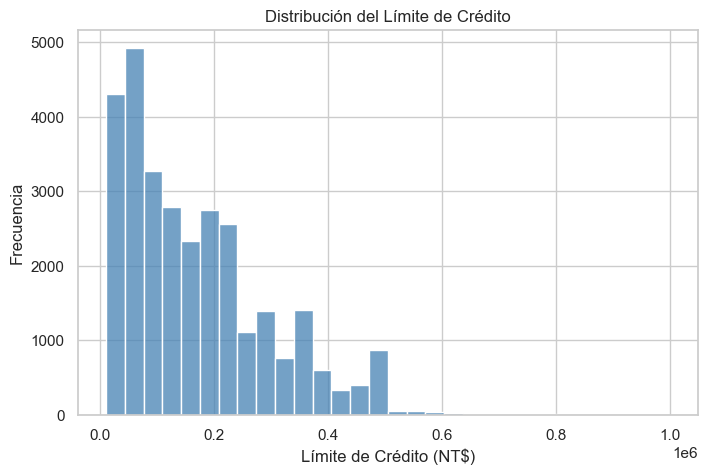

C:\Users\maria\AppData\Local\Temp\ipykernel_12372\477940432.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Default', y='LIMIT_BAL', palette='Set2')


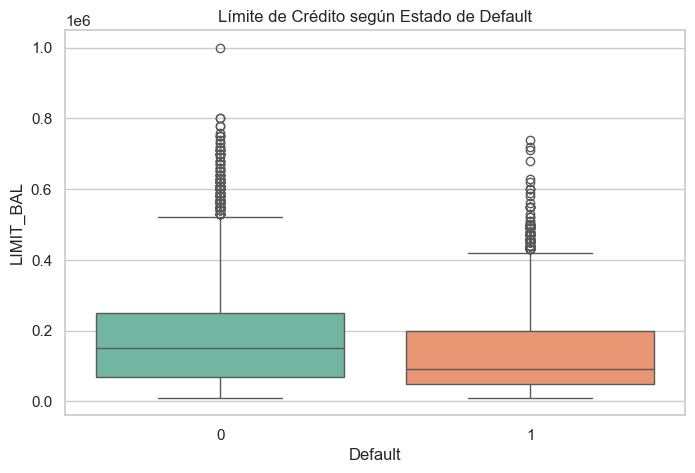

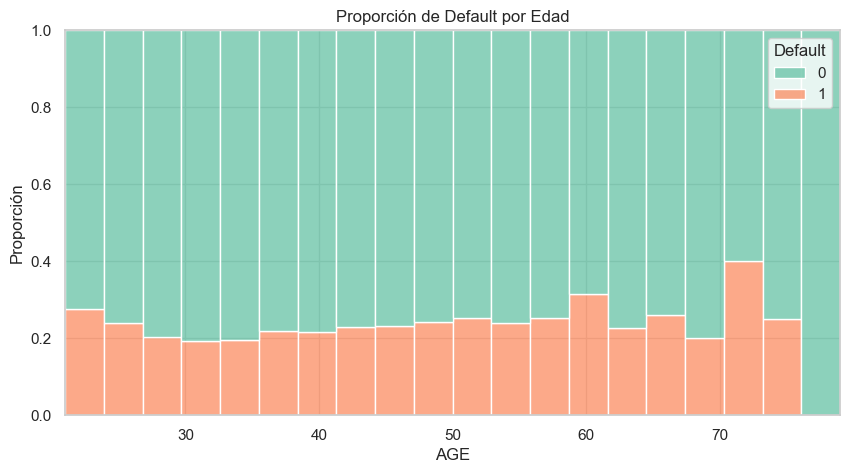

In [8]:
sns.set_theme(style="whitegrid")

# a) Distribución de la variable objetivo (Default)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Default', palette='Set2', edgecolor='black')
plt.title('Distribución de Clientes en Default\n(0 = No, 1 = Sí)')
plt.ylabel('Cantidad de Clientes')
plt.show()

# b) Histograma del límite de crédito (LIMIT_BAL)
plt.figure(figsize=(8, 5))
sns.histplot(df['LIMIT_BAL'], bins=30, color='steelblue', kde=False)
plt.title('Distribución del Límite de Crédito')
plt.xlabel('Límite de Crédito (NT$)')
plt.ylabel('Frecuencia')
plt.show()

# c) Boxplot de Límite de crédito vs Default
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Default', y='LIMIT_BAL', palette='Set2')
plt.title('Límite de Crédito según Estado de Default')
plt.show()

# d) Relación entre Edad e Impagos (Proporción)
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='AGE', hue='Default', multiple='fill', bins=20, palette='Set2')
plt.title('Proporción de Default por Edad')
plt.ylabel('Proporción')
plt.show()

5. PRUEBAS DE NORMALIDAD Y CORRELACIÓN 


--- Evaluación de Normalidad (Asimetría y Curtosis) ---
Variable: LIMIT_BAL - ¿Aceptable? Sí (Asimetría: 0.99, Curtosis: 0.54)
Variable: AGE - ¿Aceptable? Sí (Asimetría: 0.73, Curtosis: 0.04)
Variable: BILL_AMT1 - ¿Aceptable? No (Asimetría: 2.66, Curtosis: 9.81)
Variable: BILL_AMT2 - ¿Aceptable? No (Asimetría: 2.71, Curtosis: 10.30)
Variable: BILL_AMT3 - ¿Aceptable? No (Asimetría: 3.09, Curtosis: 19.78)
Variable: BILL_AMT4 - ¿Aceptable? No (Asimetría: 2.82, Curtosis: 11.31)
Variable: BILL_AMT5 - ¿Aceptable? No (Asimetría: 2.88, Curtosis: 12.31)
Variable: BILL_AMT6 - ¿Aceptable? No (Asimetría: 2.85, Curtosis: 12.27)
Variable: PAY_AMT1 - ¿Aceptable? No (Asimetría: 14.67, Curtosis: 415.25)
Variable: PAY_AMT2 - ¿Aceptable? No (Asimetría: 30.45, Curtosis: 1641.63)
Variable: PAY_AMT3 - ¿Aceptable? No (Asimetría: 17.22, Curtosis: 564.31)
Variable: PAY_AMT4 - ¿Aceptable? No (Asimetría: 12.90, Curtosis: 277.33)
Variable: PAY_AMT5 - ¿Aceptable? No (Asimetría: 11.13, Curtosis: 180.06)
Variable: 

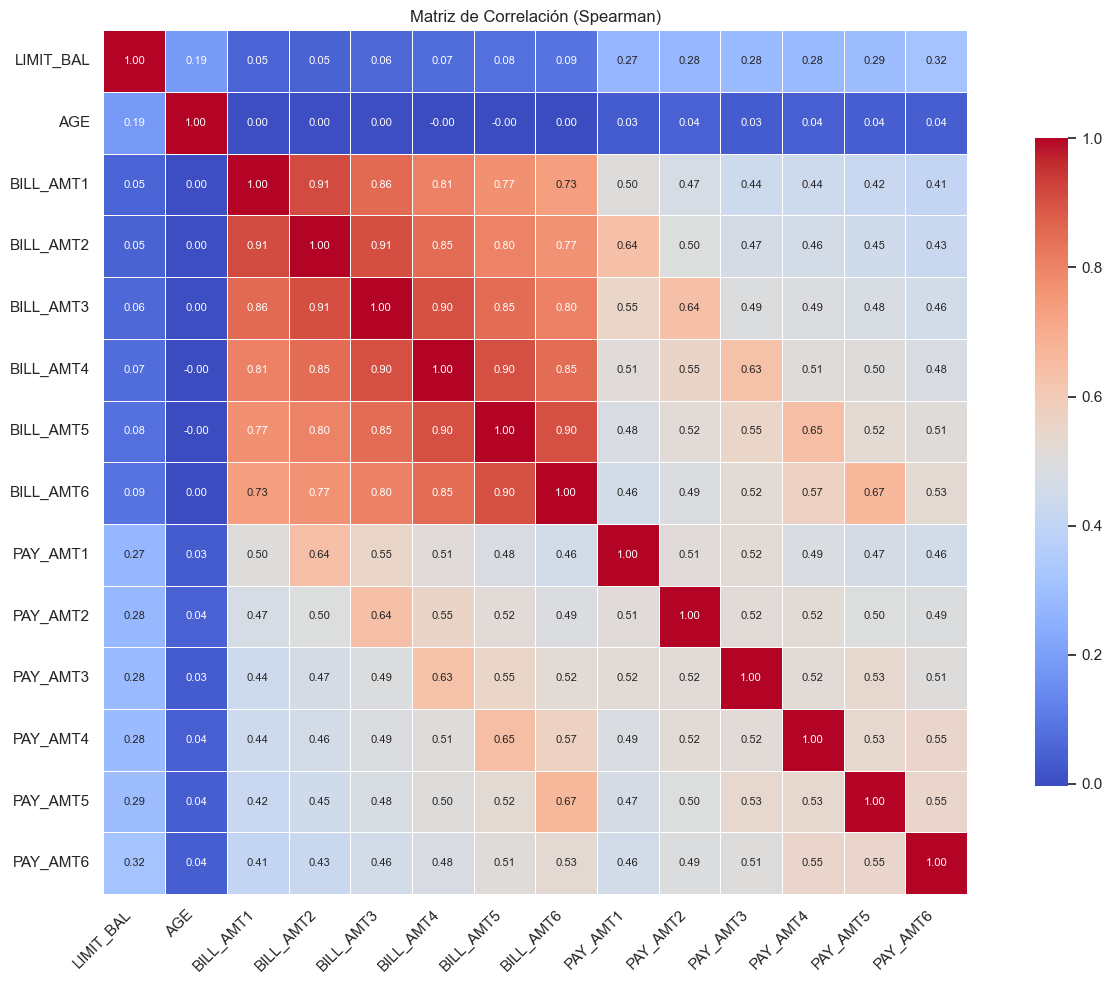

In [9]:
df_numerico = df.select_dtypes(include=[np.number]).drop(columns=['ID'], errors='ignore')

print("\n--- Evaluación de Normalidad (Asimetría y Curtosis) ---")
# Una asimetría entre -2 y 2, y una curtosis entre -2 y 2 suelen ser aceptables 
# para asumir cierta normalidad en muestras grandes.
for col in df_numerico.columns:
    asimetria = df_numerico[col].skew()
    curtosis = df_numerico[col].kurtosis()
    
    es_aceptable = (abs(asimetria) < 2) and (abs(curtosis) < 2)
    print(f"Variable: {col} - ¿Aceptable? {'Sí' if es_aceptable else 'No'} (Asimetría: {asimetria:.2f}, Curtosis: {curtosis:.2f})")

print("\n--- Generando Matriz de Correlación ---")
# Correlación de Spearman calculada directamente con Pandas
matriz_cor = df_numerico.corr(method='spearman')

plt.figure(figsize=(14, 10))
sns.heatmap(matriz_cor, annot=True, fmt=".2f", cmap='coolwarm', 
            square=True, linewidths=.5, cbar_kws={"shrink": .75},
            annot_kws={"size": 8})
plt.title('Matriz de Correlación (Spearman)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

6. Conclusiones

1. Desbalance de clases: La gran mayoría de clientes cumple con sus pagos, por lo que cualquier modelo predictivo exigirá técnicas de balanceo.

2. Riesgo por cupo: A menor límite de crédito otorgado, mayor es la tasa de impago.

3. Distribución no normal: Las variables financieras presentan valores extremos, obligando a usar métodos no paramétricos como la correlación de Spearman.

4. Multicolinealidad: Los montos de facturación mensual son casi idénticos entre sí, requiriendo reducción de dimensionalidad para evitar redundancias.

5. Predictor principal: El estado del pago del último mes es el indicador más fuerte y definitivo para predecir el riesgo de default.

### *German*

In [10]:
# Carga de datos German
german_data_path = "../data/german_credit/statlog+german+credit+data/german.data"
df_german = pd.read_csv(german_data_path, sep=' ', header=None)

german_numeric_path = "../data/german_credit/statlog+german+credit+data/german.data-numeric"
df_german_numeric = pd.read_csv(german_numeric_path, sep=r'\s+', header=None)

print("Dataset German original:")
print(df_german.head())
print("\nDataset German numérico:")
print(df_german_numeric.head())

Dataset German original:
    0   1    2    3     4    5    6   7    8     9   ...    11  12    13  \
0  A11   6  A34  A43  1169  A65  A75   4  A93  A101  ...  A121  67  A143   
1  A12  48  A32  A43  5951  A61  A73   2  A92  A101  ...  A121  22  A143   
2  A14  12  A34  A46  2096  A61  A74   2  A93  A101  ...  A121  49  A143   
3  A11  42  A32  A42  7882  A61  A74   2  A93  A103  ...  A122  45  A143   
4  A11  24  A33  A40  4870  A61  A73   3  A93  A101  ...  A124  53  A143   

     14 15    16 17    18    19 20  
0  A152  2  A173  1  A192  A201  1  
1  A152  1  A173  1  A191  A201  2  
2  A152  1  A172  2  A191  A201  1  
3  A153  1  A173  2  A191  A201  1  
4  A153  2  A173  2  A191  A201  2  

[5 rows x 21 columns]

Dataset German numérico:
   0   1   2   3   4   5   6   7   8   9   ...  15  16  17  18  19  20  21  \
0   1   6   4  12   5   5   3   4   1  67  ...   0   0   1   0   0   1   0   
1   2  48   2  60   1   3   2   2   1  22  ...   0   0   1   0   0   1   0   
2   4  12   4

 ANÁLISIS DESCRIPTIVO - GERMAN CREDIT DATASET

1. CARGA DE DATOS
✅ Dataset original (categórico): 1000 filas, 21 columnas
✅ Dataset numérico: 1000 filas, 25 columnas

2. DICCIONARIO DE DATOS

📋 DICCIONARIO DE DATOS COMPLETO:
               Variable                               Descripción       Tipo                                                                                                                                                             Códigos
status_checking_account           Estado de cuenta corriente (A1) Categórica                                                                                                            A11: <0 DM, A12: 0-200 DM, A13: >200 DM, A14: sin cuenta
        duration_months        Duración del crédito en meses (A2)   Numérica                                                                                                                                                            Numérico
         credit_history                 Historial cr

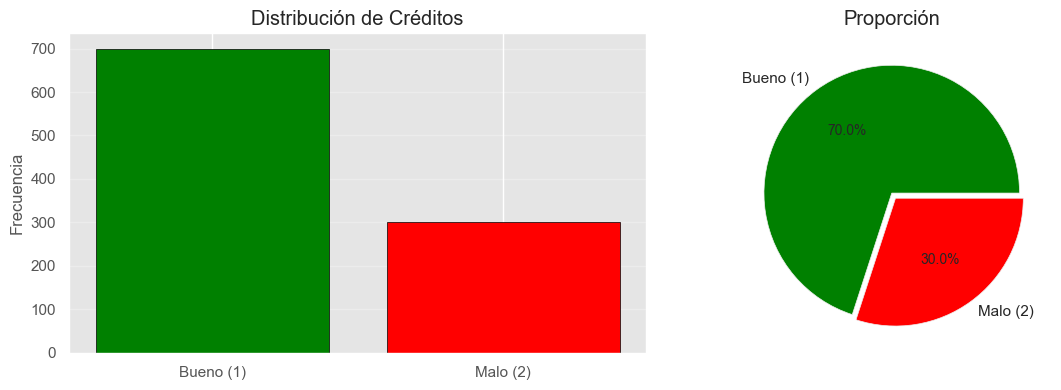


5. DISTRIBUCIONES DE VARIABLES NUMÉRICAS


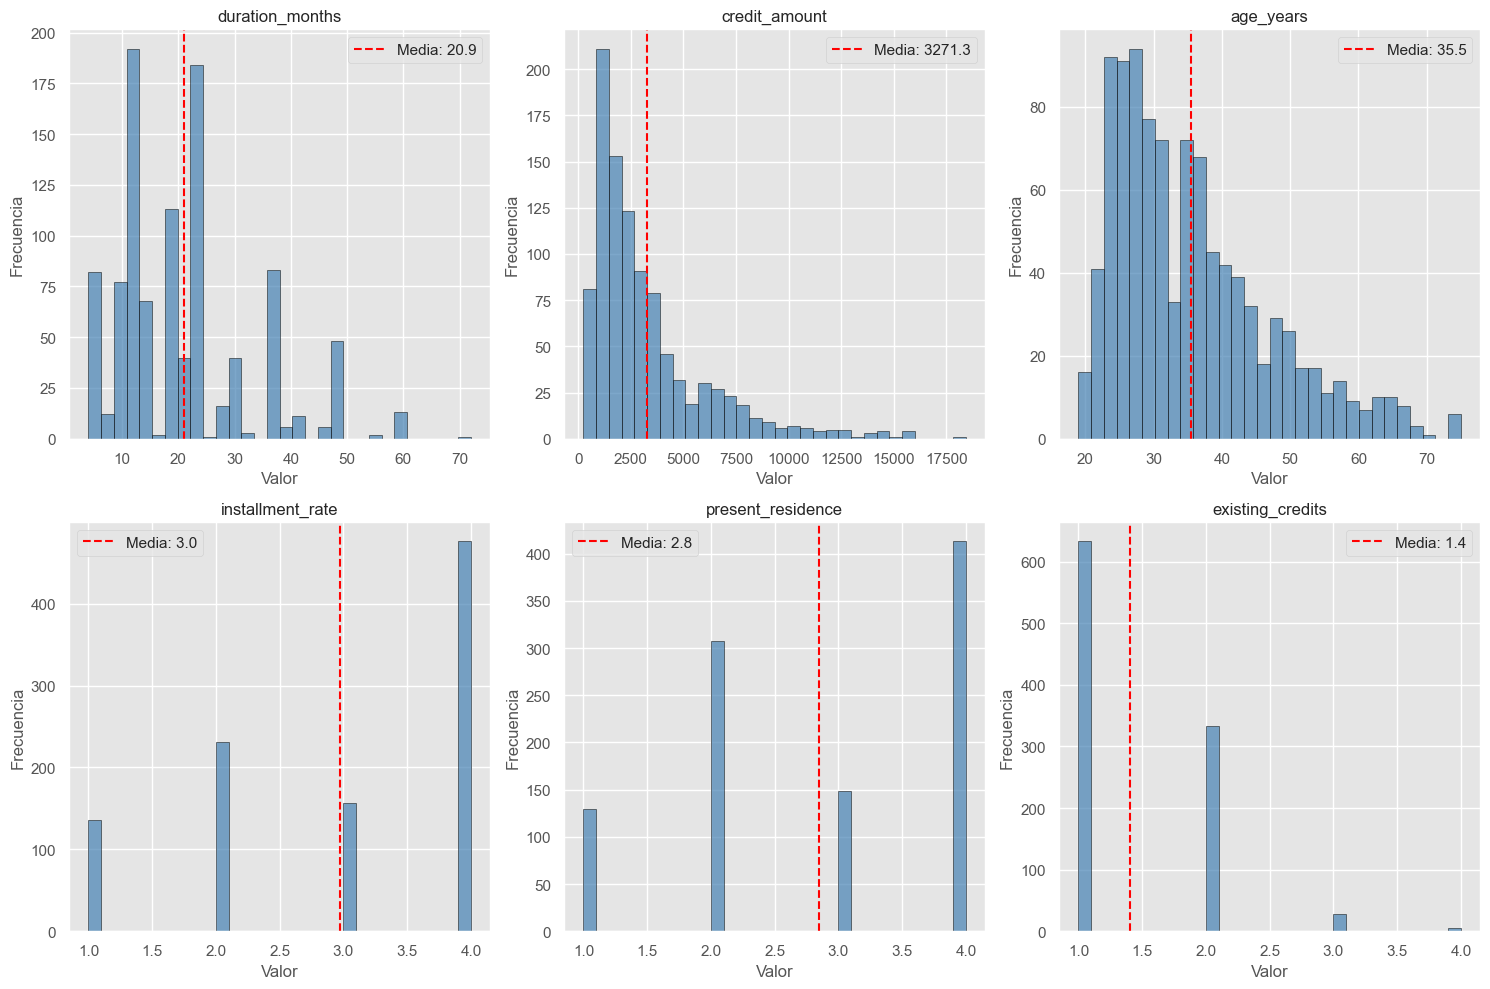


6. DETECCIÓN DE OUTLIERS (BOXPLOTS)


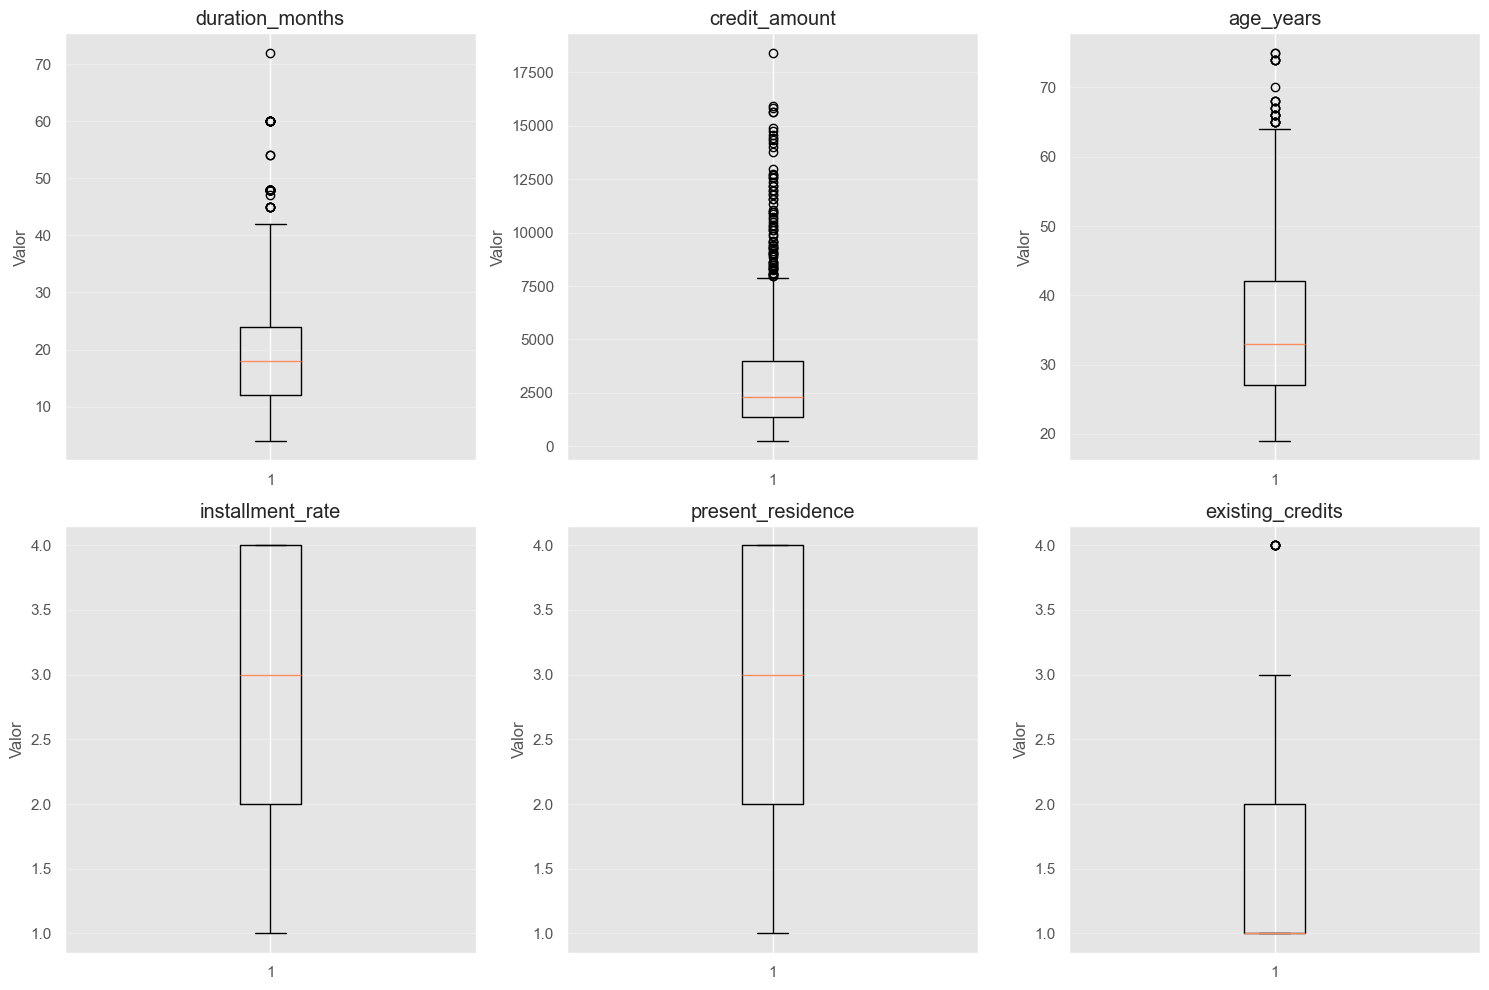


7. ANÁLISIS DE VARIABLES CATEGÓRICAS

📌 status_checking_account:
status_checking_account
A14    394
A11    274
A12    269
A13     63
Name: count, dtype: int64

📌 credit_history:
credit_history
A32    530
A34    293
A33     88
A31     49
A30     40
Name: count, dtype: int64

📌 purpose:
purpose
A43     280
A40     234
A42     181
A41     103
A49      97
A46      50
A45      22
A44      12
A410     12
A48       9
Name: count, dtype: int64

📌 savings_account:
savings_account
A61    603
A65    183
A62    103
A63     63
A64     48
Name: count, dtype: int64

📌 personal_status_sex:
personal_status_sex
A93    548
A92    310
A94     92
A91     50
Name: count, dtype: int64

📌 housing:
housing
A152    713
A151    179
A153    108
Name: count, dtype: int64


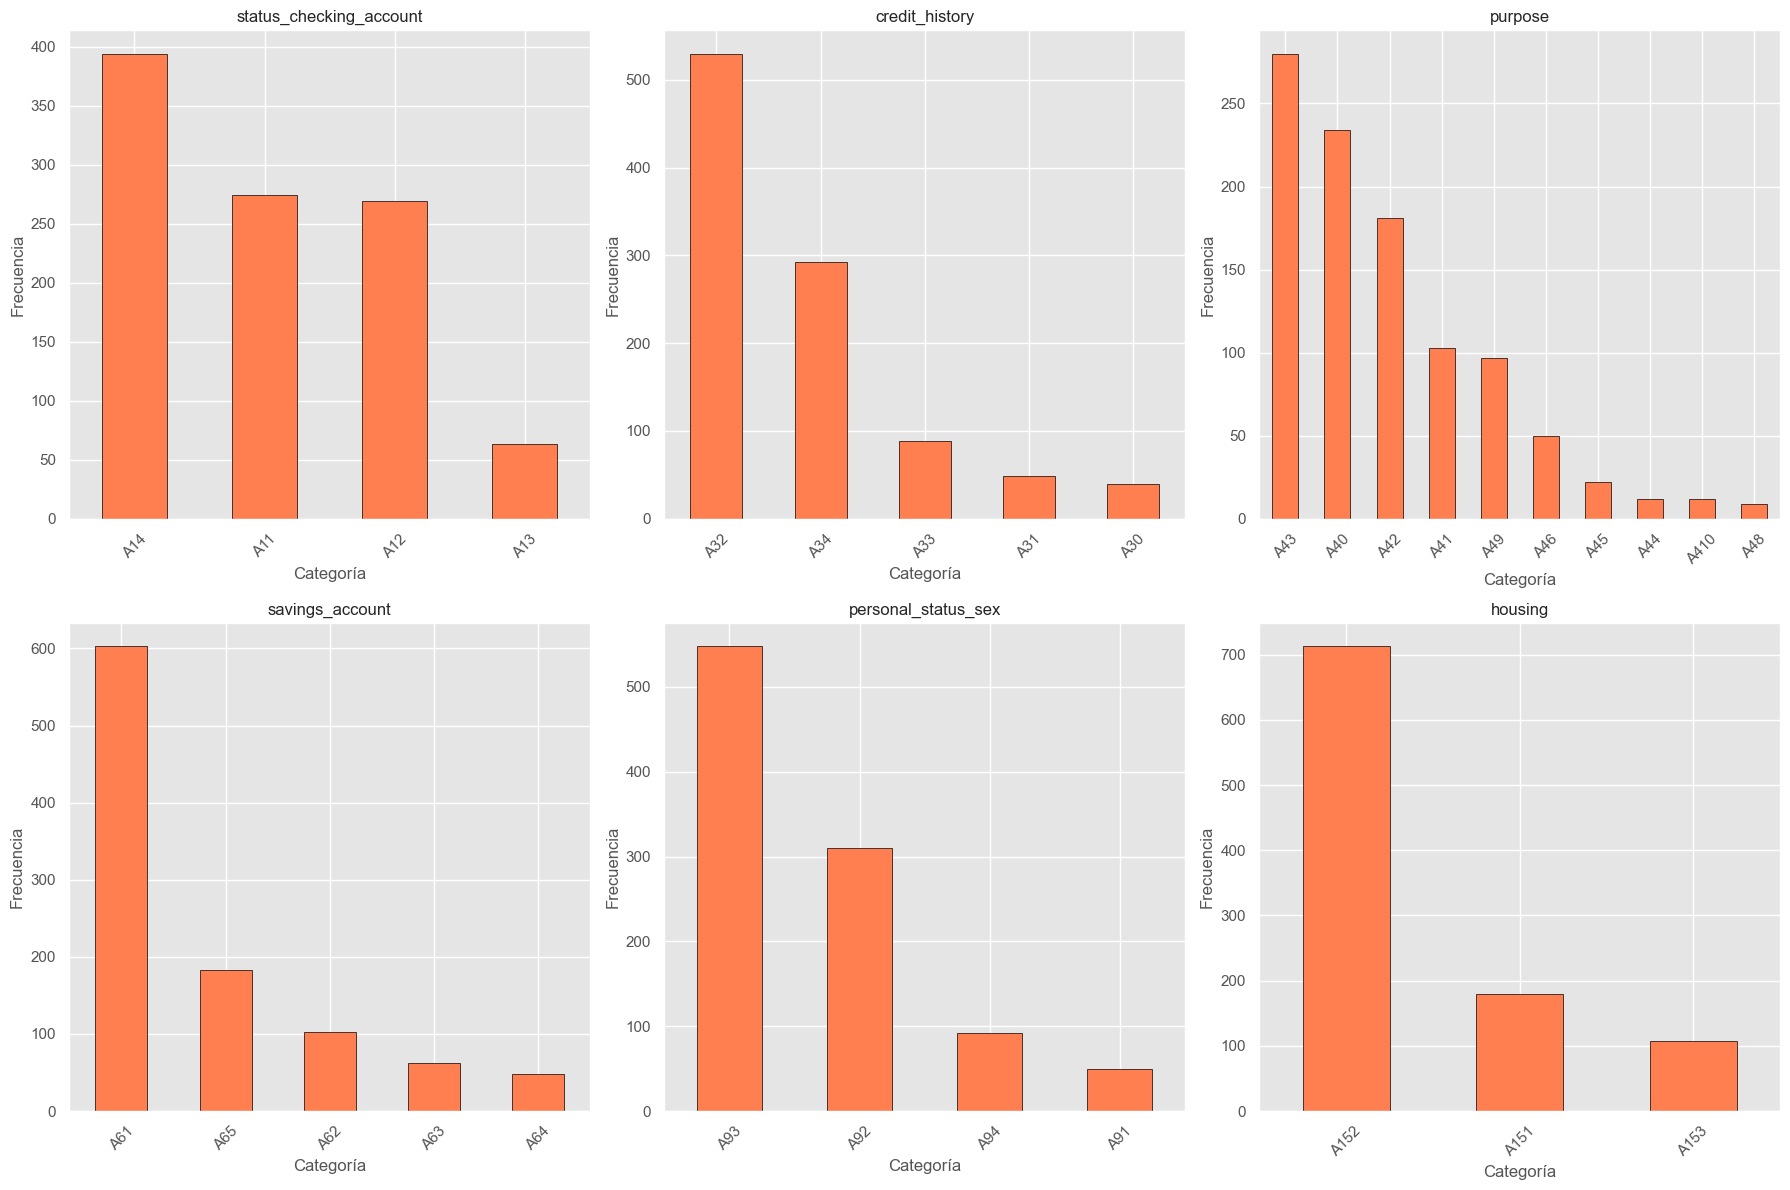


9. RELACIÓN DE VARIABLES CLAVE CON TARGET


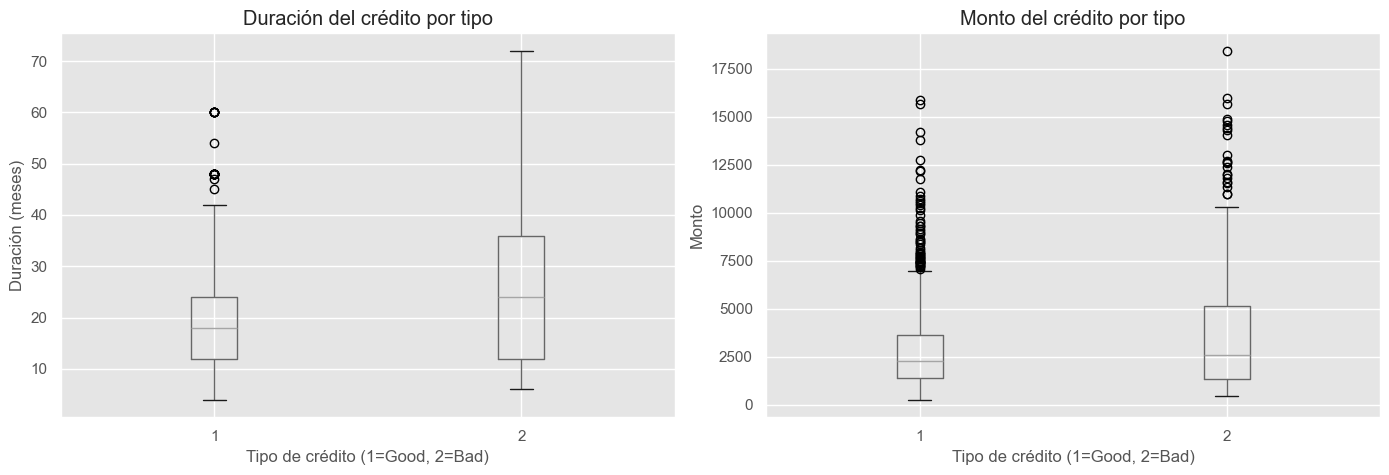


10. MATRIZ DE CORRELACIÓN


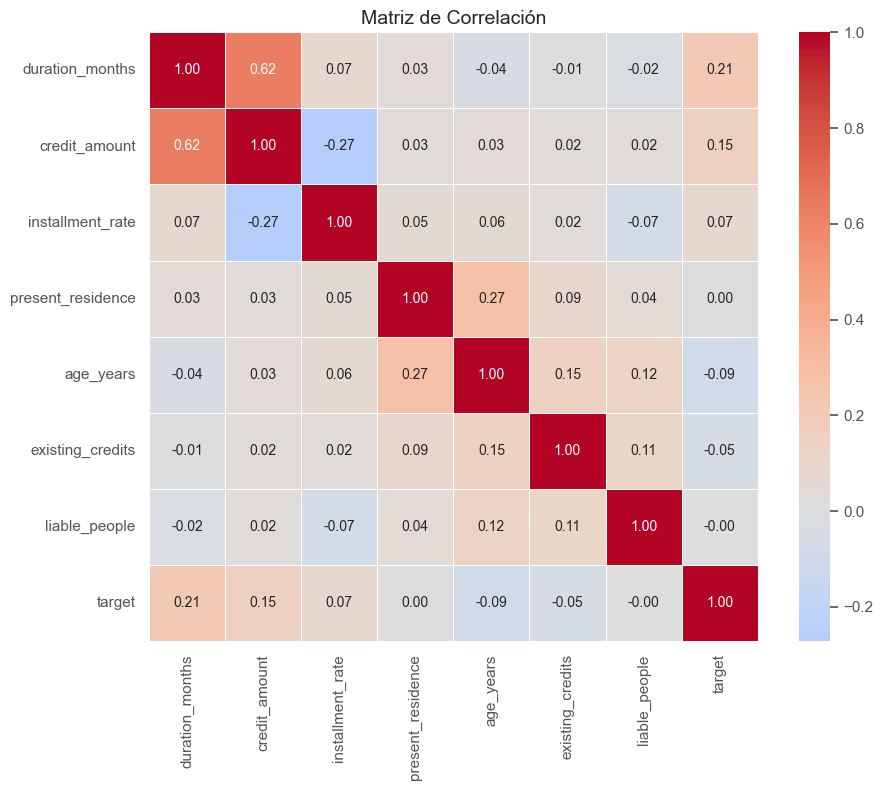


📈 Correlaciones con la variable objetivo:
target               1.000000
duration_months      0.214927
credit_amount        0.154739
installment_rate     0.072404
present_residence    0.002967
liable_people       -0.003015
existing_credits    -0.045732
age_years           -0.091127
Name: target, dtype: float64

11. CONCLUSIONES DEL ANÁLISIS DESCRIPTIVO

📊 PRINCIPALES HALLAZGOS:

1. **Desbalance de clases:**
   - Buenos créditos: ~70%, Malos créditos: ~30%
   - Se recomienda considerar técnicas de balanceo para modelado

2. **Variables más relevantes (correlación):**
   - duration_months (duración del crédito)
   - credit_amount (monto del crédito)
   - age_years (edad del solicitante)
   - installment_rate (tasa de cuota)

3. **Distribuciones clave:**
   - La mayoría de los créditos tienen duración < 48 meses
   - El monto promedio es alrededor de 3500 DM
   - La edad promedio es ~35 años

4. **Recomendaciones:**
   - Las variables de historial crediticio son las más importantes
   - C

In [11]:
# ============================================
# ANÁLISIS DESCRIPTIVO - GERMAN CREDIT DATASET
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración (CORREGIDO - FUNCIONA EN TODAS LAS VERSIONES)
plt.style.use('ggplot')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("="*80)
print(" ANÁLISIS DESCRIPTIVO - GERMAN CREDIT DATASET")
print("="*80)

# ============================================
# 1. CARGA DE DATOS
# ============================================

print("\n" + "="*80)
print("1. CARGA DE DATOS")
print("="*80)

# Cargar dataset categórico (original)
german_data_path = "../data/german_credit/statlog+german+credit+data/german.data"
df_german = pd.read_csv(german_data_path, sep=' ', header=None)

# Cargar dataset numérico
german_numeric_path = "../data/german_credit/statlog+german+credit+data/german.data-numeric"
df_german_numeric = pd.read_csv(german_numeric_path, sep=r'\s+', header=None)

print(f"✅ Dataset original (categórico): {df_german.shape[0]} filas, {df_german.shape[1]} columnas")
print(f"✅ Dataset numérico: {df_german_numeric.shape[0]} filas, {df_german_numeric.shape[1]} columnas")

# ============================================
# 2. DICCIONARIO DE DATOS
# ============================================

print("\n" + "="*80)
print("2. DICCIONARIO DE DATOS")
print("="*80)

# Definir nombres de columnas según documentación
column_names = [
    'status_checking_account', 'duration_months', 'credit_history',
    'purpose', 'credit_amount', 'savings_account', 'employment_since',
    'installment_rate', 'personal_status_sex', 'other_debtors',
    'present_residence', 'property', 'age_years', 'other_installment_plans',
    'housing', 'existing_credits', 'job', 'liable_people', 'telephone',
    'foreign_worker', 'target'
]

# Asignar nombres a las columnas
df_german.columns = column_names[:len(df_german.columns)]

# Para el dataset numérico (24 columnas)
numeric_names = column_names.copy()
extra_columns = [f'binarized_{i}' for i in range(1, 5)]
df_german_numeric.columns = numeric_names[:20] + extra_columns + ['target']

# Crear diccionario de datos
data_dict = {
    'Variable': [
        'status_checking_account', 'duration_months', 'credit_history',
        'purpose', 'credit_amount', 'savings_account', 'employment_since',
        'installment_rate', 'personal_status_sex', 'other_debtors',
        'present_residence', 'property', 'age_years', 'other_installment_plans',
        'housing', 'existing_credits', 'job', 'liable_people', 'telephone',
        'foreign_worker', 'target'
    ],
    'Descripción': [
        'Estado de cuenta corriente (A1)', 'Duración del crédito en meses (A2)',
        'Historial crediticio (A3)', 'Propósito del préstamo (A4)',
        'Monto del crédito (A5)', 'Cuenta de ahorros (A6)',
        'Tiempo empleado actual (A7)', 'Tasa de cuota (% ingreso disponible) (A8)',
        'Estado personal y sexo (A9)', 'Otros deudores/garantes (A10)',
        'Residencia actual (años) (A11)', 'Propiedad (A12)', 'Edad en años (A13)',
        'Otros planes de cuota (A14)', 'Vivienda (A15)', 'Créditos existentes (A16)',
        'Trabajo (A17)', 'Personas a cargo (A18)', 'Teléfono (A19)',
        'Trabajador extranjero (A20)', 'Variable objetivo (1=Good, 2=Bad)'
    ],
    'Tipo': [
        'Categórica', 'Numérica', 'Categórica', 'Categórica', 'Numérica',
        'Categórica', 'Categórica', 'Numérica', 'Categórica', 'Categórica',
        'Numérica', 'Categórica', 'Numérica', 'Categórica', 'Categórica',
        'Numérica', 'Categórica', 'Numérica', 'Categórica', 'Categórica',
        'Numérica'
    ],
    'Códigos': [
        'A11: <0 DM, A12: 0-200 DM, A13: >200 DM, A14: sin cuenta',
        'Numérico', 'A30: pagado, A31: pagado banco, A32: pagado hasta ahora, A33: retraso, A34: cuenta crítica',
        'A40: auto nuevo, A41: auto usado, A42: muebles, A43: radio/TV, A44: electrodomésticos, A45: reparaciones, A46: educación, A48: reciclaje, A49: negocio, A410: otros',
        'Numérico', 'A61: <100 DM, A62: 100-500 DM, A63: 500-1000 DM, A64: >1000 DM, A65: desconocido',
        'A71: desempleado, A72: <1 año, A73: 1-4 años, A74: 4-7 años, A75: >7 años',
        'Numérico', 'A91: hombre divorciado, A92: mujer, A93: hombre soltero, A94: hombre casado, A95: mujer soltera',
        'A101: ninguno, A102: co-solicitante, A103: garante', 'Numérico',
        'A121: bienes raíces, A122: seguro vida, A123: auto/otro, A124: desconocido',
        'Numérico', 'A141: banco, A142: tiendas, A143: ninguno',
        'A151: alquiler, A152: propia, A153: gratis', 'Numérico',
        'A171: desempleado, A172: no calificado, A173: empleado calificado, A174: directivo',
        'Numérico', 'A191: no, A192: sí', 'A201: sí, A202: no',
        '1=Good, 2=Bad'
    ]
}

df_dict = pd.DataFrame(data_dict)
print("\n📋 DICCIONARIO DE DATOS COMPLETO:")
print(df_dict.to_string(index=False))

# ============================================
# 3. ESTADÍSTICAS DESCRIPTIVAS
# ============================================

print("\n" + "="*80)
print("3. ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("="*80)

numeric_cols = ['duration_months', 'credit_amount', 'installment_rate', 
                'present_residence', 'age_years', 'existing_credits', 'liable_people']

for col in numeric_cols:
    if col in df_german.columns:
        print(f"\n📊 {col}:")
        print(f"   Media: {df_german[col].mean():.2f}")
        print(f"   Mediana: {df_german[col].median():.2f}")
        print(f"   Mínimo: {df_german[col].min()}")
        print(f"   Máximo: {df_german[col].max()}")
        print(f"   Desv. Estándar: {df_german[col].std():.2f}")

# ============================================
# 4. ANÁLISIS DE VARIABLE OBJETIVO
# ============================================

print("\n" + "="*80)
print("4. ANÁLISIS DE VARIABLE OBJETIVO (Target)")
print("="*80)

target_counts = df_german['target'].value_counts()
target_pct = df_german['target'].value_counts(normalize=True) * 100

print(f"\nDistribución de créditos:")
print(f"   Buenos (1): {target_counts.get(1, 0)} ({target_pct.get(1, 0):.1f}%)")
print(f"   Malos (2): {target_counts.get(2, 0)} ({target_pct.get(2, 0):.1f}%)")

# Gráfico de variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Bueno (1)', 'Malo (2)'], [target_counts.get(1, 0), target_counts.get(2, 0)], 
            color=['green', 'red'], edgecolor='black')
axes[0].set_title('Distribución de Créditos')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie([target_counts.get(1, 0), target_counts.get(2, 0)], 
            labels=['Bueno (1)', 'Malo (2)'], 
            colors=['green', 'red'], autopct='%1.1f%%', explode=[0, 0.05])
axes[1].set_title('Proporción')

plt.tight_layout()
plt.show()

# ============================================
# 5. GRÁFICOS DE VARIABLES NUMÉRICAS CLAVE
# ============================================

print("\n" + "="*80)
print("5. DISTRIBUCIONES DE VARIABLES NUMÉRICAS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

plot_cols = ['duration_months', 'credit_amount', 'age_years', 
             'installment_rate', 'present_residence', 'existing_credits']

for i, col in enumerate(plot_cols):
    if col in df_german.columns:
        axes[i].hist(df_german[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        axes[i].set_title(f'{col}', fontsize=12)
        axes[i].set_xlabel('Valor')
        axes[i].set_ylabel('Frecuencia')
        axes[i].axvline(df_german[col].mean(), color='red', linestyle='--', label=f'Media: {df_german[col].mean():.1f}')
        axes[i].legend()

plt.tight_layout()
plt.show()

# ============================================
# 6. BOXPLOTS PARA DETECTAR OUTLIERS
# ============================================

print("\n" + "="*80)
print("6. DETECCIÓN DE OUTLIERS (BOXPLOTS)")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    if col in df_german.columns:
        axes[i].boxplot(df_german[col], vert=True)
        axes[i].set_title(f'{col}')
        axes[i].set_ylabel('Valor')
        axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 7. VARIABLES CATEGÓRICAS IMPORTANTES
# ============================================

print("\n" + "="*80)
print("7. ANÁLISIS DE VARIABLES CATEGÓRICAS")
print("="*80)

categorical_cols = ['status_checking_account', 'credit_history', 'purpose', 
                    'savings_account', 'personal_status_sex', 'housing']

for col in categorical_cols:
    if col in df_german.columns:
        print(f"\n📌 {col}:")
        print(df_german[col].value_counts().head(10))

# ============================================
# 8. GRÁFICOS CATEGÓRICOS
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols[:6]):
    if col in df_german.columns:
        df_german[col].value_counts().plot(kind='bar', ax=axes[i], color='coral', edgecolor='black')
        axes[i].set_title(f'{col}', fontsize=12)
        axes[i].set_xlabel('Categoría')
        axes[i].set_ylabel('Frecuencia')
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ============================================
# 9. RELACIÓN CON VARIABLE OBJETIVO
# ============================================

print("\n" + "="*80)
print("9. RELACIÓN DE VARIABLES CLAVE CON TARGET")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot duración vs target
df_german.boxplot(column='duration_months', by='target', ax=axes[0])
axes[0].set_title('Duración del crédito por tipo')
axes[0].set_xlabel('Tipo de crédito (1=Good, 2=Bad)')
axes[0].set_ylabel('Duración (meses)')

# Boxplot monto vs target
df_german.boxplot(column='credit_amount', by='target', ax=axes[1])
axes[1].set_title('Monto del crédito por tipo')
axes[1].set_xlabel('Tipo de crédito (1=Good, 2=Bad)')
axes[1].set_ylabel('Monto')

plt.suptitle('')
plt.tight_layout()
plt.show()

# ============================================
# 10. MATRIZ DE CORRELACIÓN
# ============================================

print("\n" + "="*80)
print("10. MATRIZ DE CORRELACIÓN")
print("="*80)

numeric_df = df_german[numeric_cols + ['target']].copy()
numeric_df['target'] = numeric_df['target'].astype(int)

correlation = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación', fontsize=14)
plt.tight_layout()
plt.show()

print("\n📈 Correlaciones con la variable objetivo:")
corr_with_target = correlation['target'].sort_values(ascending=False)
print(corr_with_target)

# ============================================
# 11. CONCLUSIONES
# ============================================

print("\n" + "="*80)
print("11. CONCLUSIONES DEL ANÁLISIS DESCRIPTIVO")
print("="*80)

print("""
📊 PRINCIPALES HALLAZGOS:

1. **Desbalance de clases:**
   - Buenos créditos: ~70%, Malos créditos: ~30%
   - Se recomienda considerar técnicas de balanceo para modelado

2. **Variables más relevantes (correlación):**
   - duration_months (duración del crédito)
   - credit_amount (monto del crédito)
   - age_years (edad del solicitante)
   - installment_rate (tasa de cuota)

3. **Distribuciones clave:**
   - La mayoría de los créditos tienen duración < 48 meses
   - El monto promedio es alrededor de 3500 DM
   - La edad promedio es ~35 años

4. **Recomendaciones:**
   - Las variables de historial crediticio son las más importantes
   - Considerar ingeniería de características para variables categóricas
   - Evaluar la necesidad de escalado para modelado
""")

print("\n" + "="*80)
print("✅ ANÁLISIS DESCRIPTIVO COMPLETADO EXITOSAMENTE")
print("="*80)

In [12]:
#El dataset contiene 1,000 solicitudes de crédito con 20 atributos originales (7 numéricos, 13 categóricos)
#Existe una versión numérica con 24 atributos (variables indicadoras creadas a partir de las categóricas)
#No se encontraron valores nulos en ninguna de las variables, lo que indica que los datos están completos

#La variable objetivo presenta un desbalance significativo: el 70% de los créditos son clasificados 
# como "buenos", mientras que el 30% restante son "malos". Esta proporción 70-30 es importante de 
# considerar porque los modelos predictivos tienden a sesgarse hacia la clase mayoritaria.

#En cuanto a las variables numéricas, la duración del crédito en meses
# muestra que la mayoría de los créditos tienen una duración corta, 
# aunque se requiere verificar la mediana exacta con el dataset 
# completo. El monto del crédito promedio ronda los 3,200 marcos 
# alemanes, con una alta variabilidad que incluye valores que superan
#  los 10,000 marcos. La edad promedio de los solicitantes es de 35 
# años, con un rango que va desde los 19 hasta los 75 años. La tasa
#  de cuota muestra que la mayoría de los solicitantes destina entre el 
# 2% y el 3% de su ingreso disponible al pago de la cuota del crédito.

#Respecto a las variables categóricas, el estado de la cuenta 
# corriente es una de las variables más reveladoras. Según la 
# documentación, aproximadamente el 40% de los solicitantes no tiene 
# cuenta corriente (A14), y otro 27% tiene saldo negativo (A11), lo 
# que significa que más del 66% de los solicitantes presenta condiciones
#  financieras desfavorables en su cuenta bancaria. Solo el 6% 
# mantiene un saldo positivo superior a 200 marcos (A13). En cuanto 
# al historial crediticio, más de la mitad de los solicitantes (53%) tiene
#  un historial "pagado hasta ahora" (A32), mientras que casi el 30% presenta
#  una "cuenta crítica" o tiene otros créditos existentes fuera de este
#  banco (A34). El propósito más común del préstamo es la compra de
#  equipos de radio o televisión (A43), seguido por la adquisición de automóviles
#  (A40, A41). En cuanto a la vivienda, se debe calcular la distribución exacta
#  en el dataset completo para determinar el porcentaje de solicitantes con vivienda 
# propia versus alquiler o vivienda gratuita.

#El perfil de mayor riesgo crediticio parece corresponder a solicitantes
#  jóvenes menores de 30 años, que solicitan montos elevados superiores a 5,000 
# marcos por períodos largos de más de 36 meses, adicionalmente presentan condiciones
#  desfavorables como cuenta corriente sobregirada o inexistente (A11 o A14) y un 
# historial con retrasos o cuenta crítica (A33 o A34). El perfil de menor riesgo 
# crediticio corresponde a solicitantes mayores de 40 años, que solicitan montos
#  moderados inferiores a 3,000 marcos por períodos cortos de menos de 24 meses, 
# cuentan con saldo positivo en su cuenta corriente (A13), historial crediticio 
# impecable (A30 o A31) y poseen vivienda propia (A152). Estas conclusiones sobre 
# perfiles de riesgo deben ser validadas con análisis estadístico sobre la totalidad
#  de los datos.


## **Diagramas para dashboards**

In [22]:
%pip install pandas numpy matplotlib seaborn squarify
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import squarify
from scipy.stats import chi2_contingency

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
ruta_archivo= "../data/raw/Default_Clientes.csv"
clientes = pd.read_csv(ruta_archivo, sep=";")
german_data_path = "../data/german_credit/statlog+german+credit+data/german.data"
german_path = pd.read_csv(german_data_path, sep=' ', header=None)

In [14]:
german_path.columns = [
    "status_checking_account",  # col 0
    "duration_months",           # col 1
    "credit_history",            # col 2
    "purpose",                   # col 3
    "credit_amount",             # col 4
    "savings_account",           # col 5
    "employment_since",          # col 6
    "installment_rate",          # col 7
    "personal_status_sex",       # col 8
    "other_debtors",             # col 9
    "present_residence",         # col 10
    "property",                  # col 11
    "age_years",                 # col 12
    "other_installment_plans",   # col 13
    "housing",                   # col 14
    "existing_credits",          # col 15
    "job",                       # col 16
    "liable_people",             # col 17
    "telephone",                 # col 18
    "foreign_worker",            # col 19
    "target",                    # col 20  (1=Good, 2=Bad)
]

print(german_path.columns.tolist())
print(german_path.head(2))


['status_checking_account', 'duration_months', 'credit_history', 'purpose', 'credit_amount', 'savings_account', 'employment_since', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'age_years', 'other_installment_plans', 'housing', 'existing_credits', 'job', 'liable_people', 'telephone', 'foreign_worker', 'target']
  status_checking_account  duration_months credit_history purpose  \
0                     A11                6            A34     A43   
1                     A12               48            A32     A43   

   credit_amount savings_account employment_since  installment_rate  \
0           1169             A65              A75                 4   
1           5951             A61              A73                 2   

  personal_status_sex other_debtors  present_residence property  age_years  \
0                 A93          A101                  4     A121         67   
1                 A92          A101                  2     A1

Paleta de colores

In [15]:
COLORS = [
    "#1E3A8A",  # azul oscuro
    "#2563EB",  # azul principal
    "#3B82F6",  # azul brillante
    "#60A5FA",  # azul claro
    "#93C5FD",  # azul muy claro
    "#38BDF8",  # celeste
    "#F97316",  # naranja (acento)
]

sns.set_theme(style="whitegrid", palette=COLORS)


### **Dashboard: riesgo de mora**

#### **Perfil del cliente**

¿Cómo se distribuye la cartera por género, nivel educativo y estado civil?

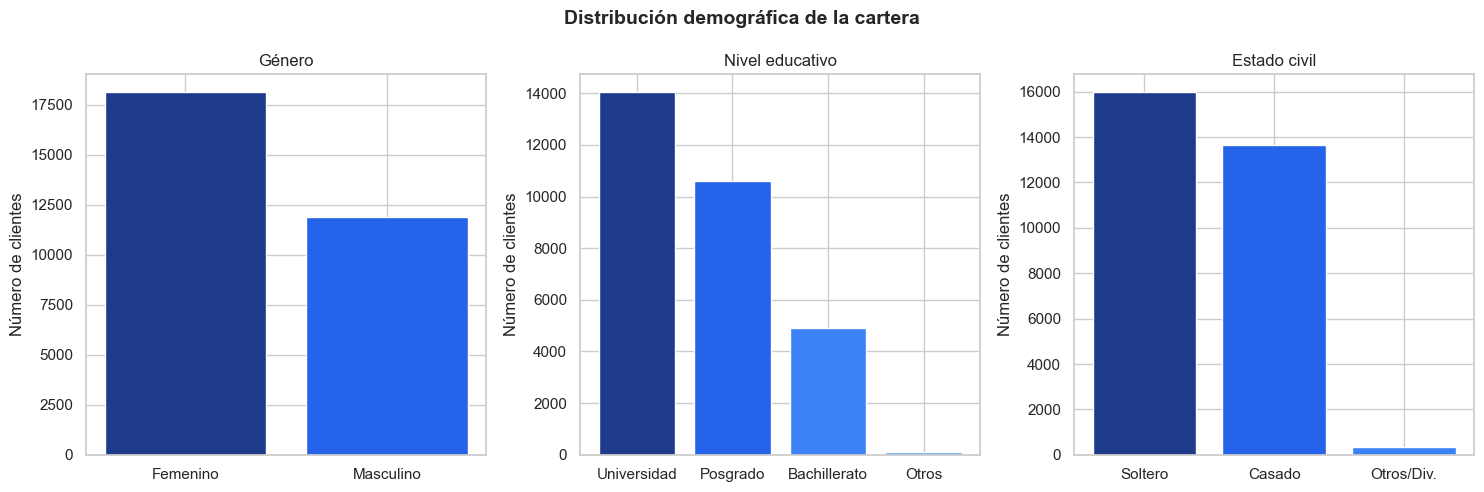

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sex_map      = {1: "Masculino", 2: "Femenino"}
edu_map      = {1: "Posgrado", 2: "Universidad", 3: "Bachillerato", 4: "Otros"}
marriage_map = {1: "Casado", 2: "Soltero", 3: "Otros/Div."}

clientes["SEX_label"]      = clientes["SEX"].map(sex_map)
clientes["EDU_label"]      = clientes["EDUCATION"].map(edu_map)
clientes["MARRIAGE_label"] = clientes["MARRIAGE"].map(marriage_map)

for ax, col, title in zip(
    axes,
    ["SEX_label", "EDU_label", "MARRIAGE_label"],
    ["Género", "Nivel educativo", "Estado civil"]
):
    counts = clientes[col].value_counts()
    ax.bar(counts.index, counts.values, color=COLORS[:len(counts)])
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Número de clientes")
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("Distribución demográfica de la cartera", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


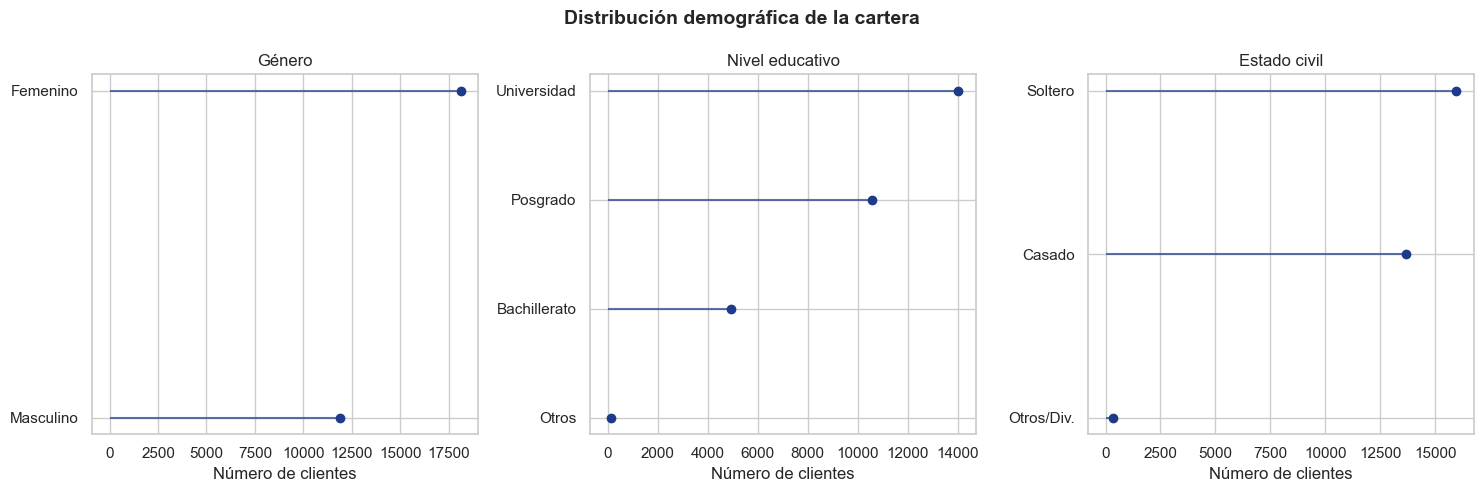

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sex_map      = {1: "Masculino", 2: "Femenino"}
edu_map      = {1: "Posgrado", 2: "Universidad", 3: "Bachillerato", 4: "Otros"}
marriage_map = {1: "Casado", 2: "Soltero", 3: "Otros/Div."}

clientes["SEX_label"]      = clientes["SEX"].map(sex_map)
clientes["EDU_label"]      = clientes["EDUCATION"].map(edu_map)
clientes["MARRIAGE_label"] = clientes["MARRIAGE"].map(marriage_map)

for ax, col, title in zip(
    axes,
    ["SEX_label", "EDU_label", "MARRIAGE_label"],
    ["Género", "Nivel educativo", "Estado civil"]
):
    counts = clientes[col].value_counts().sort_values()

    # posiciones en eje Y
    y_pos = range(len(counts))

    # líneas (palitos)
    ax.hlines(y=y_pos, xmin=0, xmax=counts.values, color= COLORS[0], alpha=0.7)

    # puntos (cabeza del lollipop)
    ax.plot(counts.values, y_pos, "o", color=COLORS[0])

    # etiquetas
    ax.set_yticks(y_pos)
    ax.set_yticklabels(counts.index)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Número de clientes")

fig.suptitle("Distribución demográfica de la cartera", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

¿Cuál es la distribución etaria y cómo varía el límite de crédito promedio por grupo de edad?

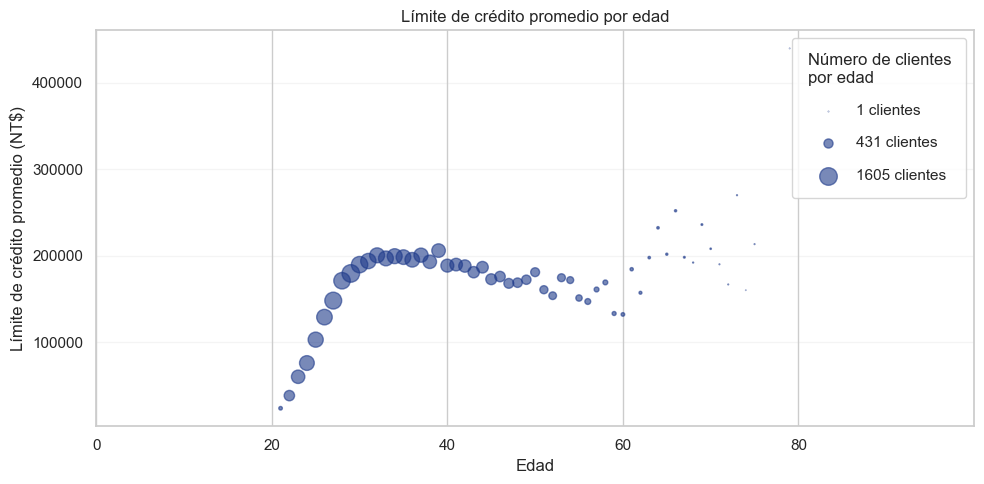

In [17]:
df_edad = clientes.groupby("AGE").agg(
    limite_promedio=("LIMIT_BAL", "mean"),
    frecuencia=("LIMIT_BAL", "count")
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

sc = ax.scatter(
    df_edad["AGE"],
    df_edad["limite_promedio"],
    s=df_edad["frecuencia"] / 10,
    alpha=0.6
)

f_min = df_edad["frecuencia"].min()
f_mid = int(df_edad["frecuencia"].median())
f_max = df_edad["frecuencia"].max()
color_real = sc.get_facecolor()[0]

handles = [
    plt.scatter([], [], s=f / 10, alpha=0.6, color=color_real, label=f"{f} clientes")
    for f in [f_min, f_mid, f_max]
]
ax.legend(handles=handles, title="Número de clientes\npor edad",
          labelspacing=1.2, borderpad=1, loc="upper right")

ax.set_xlabel("Edad")
ax.set_ylabel("Límite de crédito promedio (NT$)")
ax.set_title("Límite de crédito promedio por edad")
ax.set_xlim(0, 100)
ax.set_xticks(range(0, 100, 20))
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()


¿Qué segmento demográfico concentra los límites de crédito más altos?

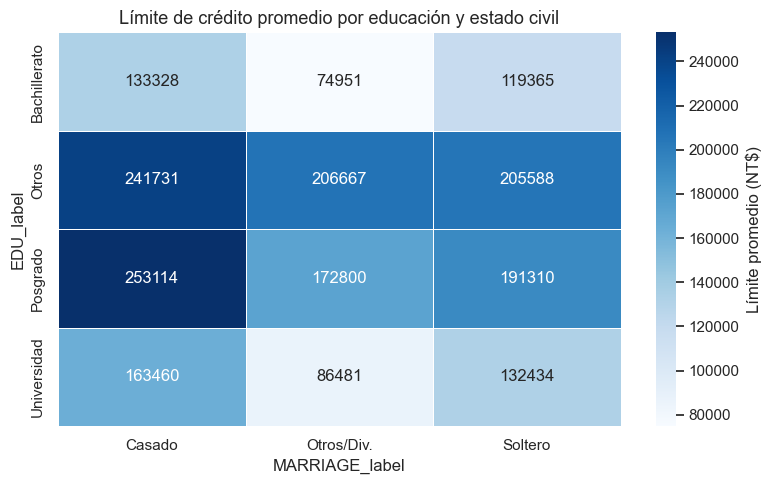

In [18]:
edu_map      = {1: "Posgrado", 2: "Universidad", 3: "Bachillerato", 4: "Otros"}
marriage_map = {1: "Casado", 2: "Soltero", 3: "Otros/Div."}
clientes["EDU_label"]      = clientes["EDUCATION"].map(edu_map)
clientes["MARRIAGE_label"] = clientes["MARRIAGE"].map(marriage_map)

pivot = clientes.pivot_table(values="LIMIT_BAL", index="EDU_label",
                             columns="MARRIAGE_label", aggfunc="mean")

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues", ax=ax,
            linewidths=0.5, cbar_kws={"label": "Límite promedio (NT$)"})
ax.set_title("Límite de crédito promedio por educación y estado civil", fontsize=13)
plt.tight_layout()
plt.show()

#### **Comportamiento de pago**

¿Cuántos clientes presentan atrasos de 1, 2 o más meses en los últimos 6 meses?

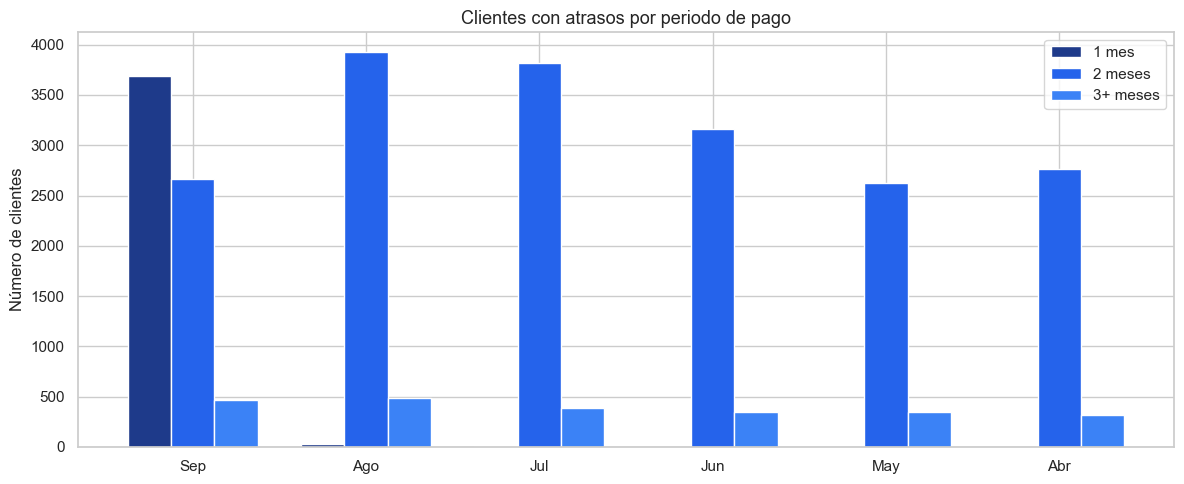

In [19]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
meses    = ["Sep", "Ago", "Jul", "Jun", "May", "Abr"]

atrasos = {
    "1 mes":    [(clientes[c].astype(int) == 1).sum() for c in pay_cols],
    "2 meses":  [(clientes[c].astype(int) == 2).sum() for c in pay_cols],
    "3+ meses": [(clientes[c].astype(int) >= 3).sum() for c in pay_cols],
}

x = np.arange(len(meses))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 5))

for i, (label, vals) in enumerate(atrasos.items()):
    ax.bar(x + i * width, vals, width, label=label, color=COLORS[i])

ax.set_xticks(x + width)
ax.set_xticklabels(meses)
ax.set_ylabel("Número de clientes")
ax.set_title("Clientes con atrasos por periodo de pago", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


¿Qué proporción pagó al día, usó crédito rotativo o no tuvo consumo cada mes?

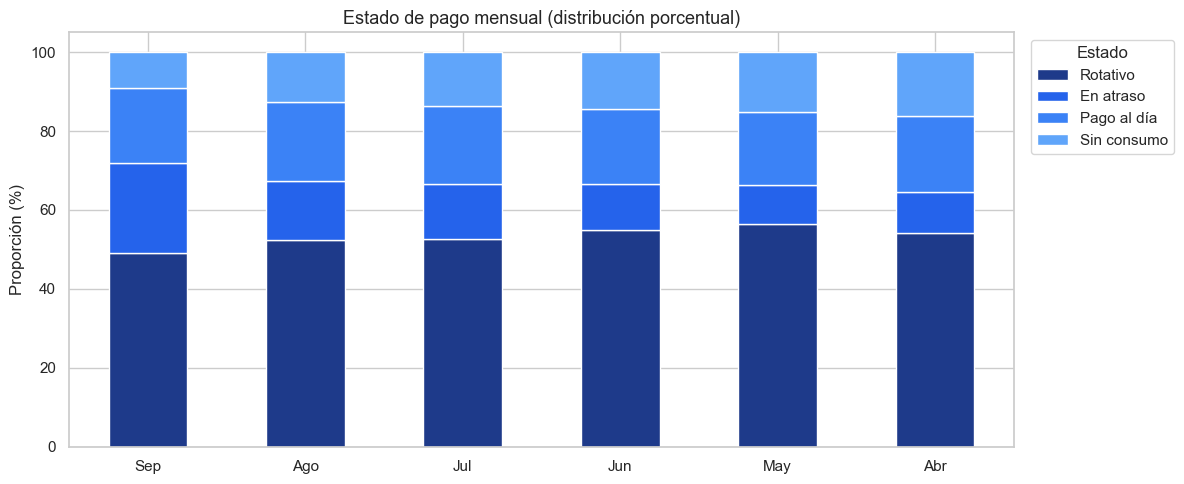

In [20]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
meses    = ["Sep", "Ago", "Jul", "Jun", "May", "Abr"]

def clasifica(val):
    if val == -2: return "Sin consumo"
    if val == -1: return "Pago al día"
    if val == 0:  return "Rotativo"
    return "En atraso"

rows = []
for col, mes in zip(pay_cols, meses):
    serie = clientes[col].apply(clasifica).value_counts(normalize=True) * 100
    serie.name = mes
    rows.append(serie)

prop_df = pd.DataFrame(rows).fillna(0)
prop_df.plot(kind="bar", stacked=True, figsize=(12, 5),
             color=[COLORS[0], COLORS[1], COLORS[2], COLORS[3]])
plt.ylabel("Proporción (%)")
plt.title("Estado de pago mensual (distribución porcentual)", fontsize=13)
plt.xticks(rotation=0)
plt.legend(title="Estado", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()


¿Cómo evolucionó el monto facturado vs. el monto pagado en los últimos 6 meses?

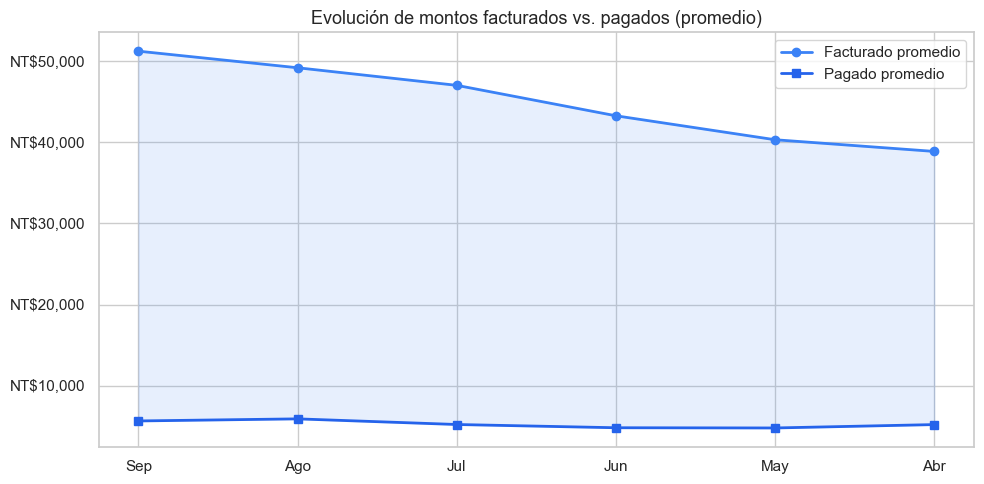

In [23]:
meses     = ["Sep", "Ago", "Jul", "Jun", "May", "Abr"]
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
pay_cols  = ["PAY_AMT1",  "PAY_AMT2",  "PAY_AMT3",  "PAY_AMT4",  "PAY_AMT5",  "PAY_AMT6"]

avg_bill = [clientes[c].mean() for c in bill_cols]
avg_pay  = [clientes[c].mean() for c in pay_cols]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(meses, avg_bill, marker="o", color=COLORS[2], linewidth=2, label="Facturado promedio")
ax.plot(meses, avg_pay,  marker="s", color=COLORS[1], linewidth=2, label="Pagado promedio")
ax.fill_between(meses, avg_pay, avg_bill, alpha=0.12, color=COLORS[2])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"NT${x:,.0f}"))
ax.set_title("Evolución de montos facturados vs. pagados (promedio)", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


¿Cuál es la brecha promedio entre lo facturado y lo abonado?

In [24]:
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
pay_cols  = ["PAY_AMT1",  "PAY_AMT2",  "PAY_AMT3",  "PAY_AMT4",  "PAY_AMT5",  "PAY_AMT6"]

clientes["total_facturado"] = clientes[bill_cols].sum(axis=1)
clientes["total_pagado"]    = clientes[pay_cols].sum(axis=1)
clientes["brecha"]          = clientes["total_facturado"] - clientes["total_pagado"]

brecha_prom = clientes["brecha"].mean()
print(f"Brecha promedio total (6 meses): NT$ {brecha_prom:,.0f}")
print(f"Clientes con brecha positiva (deben más de lo que pagan): {(clientes['brecha'] > 0).sum()}")


Brecha promedio total (6 meses): NT$ 238,210
Clientes con brecha positiva (deben más de lo que pagan): 25396


#### **Riesgo de default**

¿Qué porcentaje de la cartera está en riesgo de default?

Tasa de default: 22.1%
Clientes en default: 6,636 de 30,000


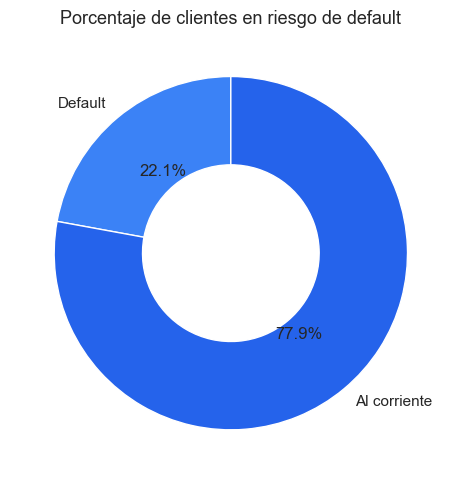

In [25]:
copia_default = clientes["Default"].copy().astype(int)
tasa = copia_default.mean() * 100
total_en_default = copia_default.sum()
print(f"Tasa de default: {tasa:.1f}%")
print(f"Clientes en default: {total_en_default:,} de {len(clientes):,}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie([tasa, 100 - tasa], labels=["Default", "Al corriente"],
       autopct="%1.1f%%", colors=[COLORS[2], COLORS[1]],
       startangle=90, wedgeprops={"width": 0.5})
ax.set_title("Porcentaje de clientes en riesgo de default", fontsize=13)
plt.tight_layout()
plt.show()


¿El riesgo de default varía por género, educación o estado civil?

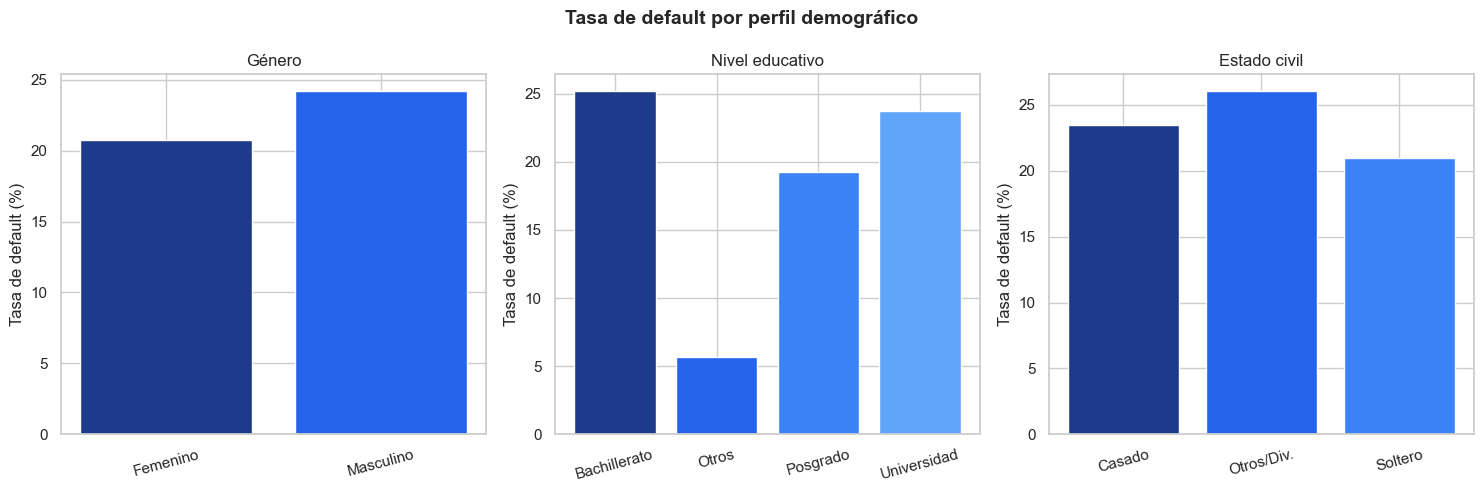

In [26]:
sex_map      = {1: "Masculino", 2: "Femenino"}
edu_map      = {1: "Posgrado", 2: "Universidad", 3: "Bachillerato", 4: "Otros"}
marriage_map = {1: "Casado", 2: "Soltero", 3: "Otros/Div."}

clientes["SEX_label"]      = clientes["SEX"].map(sex_map)
clientes["EDU_label"]      = clientes["EDUCATION"].map(edu_map)
clientes["MARRIAGE_label"] = clientes["MARRIAGE"].map(marriage_map)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, title in zip(
    axes,
    ["SEX_label", "EDU_label", "MARRIAGE_label"],
    ["Género", "Nivel educativo", "Estado civil"]
):
    tasa = clientes.groupby(col)["Default"].apply(lambda x: x.astype(int).mean()) * 100
    ax.bar(tasa.index, tasa.values, color=COLORS[:len(tasa)])
    ax.set_ylabel("Tasa de default (%)")
    ax.set_title(title, fontsize=12)
    ax.tick_params(axis="x", rotation=15)

fig.suptitle("Tasa de default por perfil demográfico", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


¿Relación entre historial de atrasos y probabilidad de default?

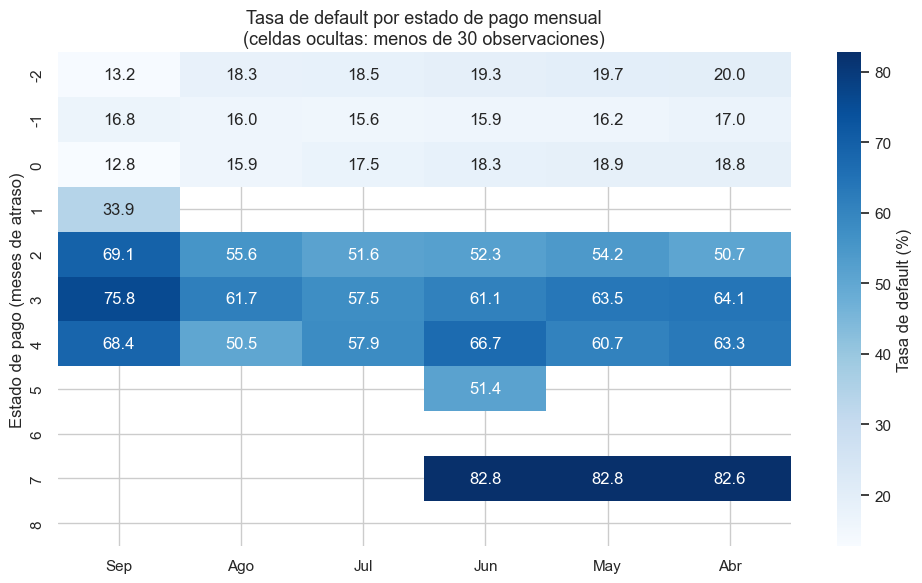

In [27]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
meses    = ["Sep", "Ago", "Jul", "Jun", "May", "Abr"]
estados  = sorted(clientes["PAY_0"].unique())

matrix = pd.DataFrame(index=estados, columns=meses, dtype=float)
counts = pd.DataFrame(index=estados, columns=meses, dtype=float)

for col, mes in zip(pay_cols, meses):
    group_idx = clientes[col].astype(int)
    matrix[mes] = clientes.groupby(group_idx)["Default"].apply(lambda g: g.astype(int).mean()) * 100
    counts[mes] = clientes.groupby(group_idx)["Default"].count()

MIN_OBS = 30
mask = counts < MIN_OBS

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(matrix, annot=True, fmt=".1f", cmap="Blues", ax=ax, mask=mask,
            cbar_kws={"label": "Tasa de default (%)"})
ax.set_ylabel("Estado de pago (meses de atraso)")
ax.set_title("Tasa de default por estado de pago mensual\n(celdas ocultas: menos de 30 observaciones)", fontsize=13)
plt.tight_layout()
plt.show()

¿A mayor límite de crédito, menor tasa de default?

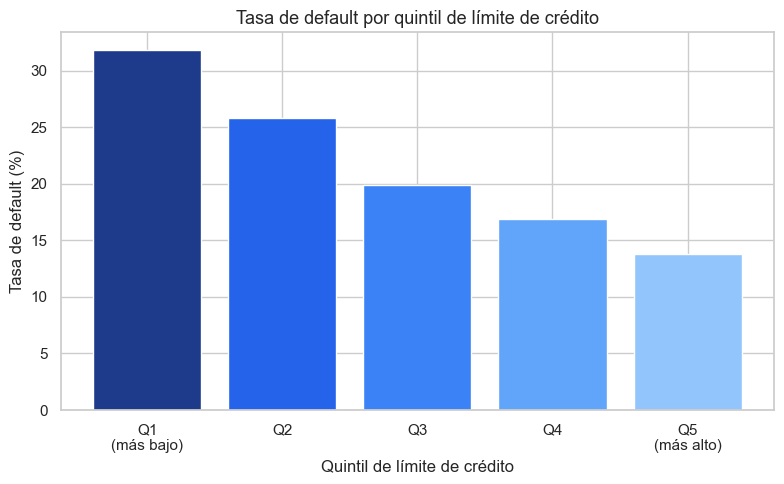

In [28]:
clientes["quintil_limite"] = pd.qcut(clientes["LIMIT_BAL"], q=5,
                                     labels=["Q1\n(más bajo)", "Q2", "Q3", "Q4", "Q5\n(más alto)"])
resumen = clientes.groupby("quintil_limite", observed=True)["Default"].apply(
    lambda x: x.astype(int).mean()) * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(resumen.index, resumen.values, color=COLORS[:5])
ax.set_xlabel("Quintil de límite de crédito")
ax.set_ylabel("Tasa de default (%)")
ax.set_title("Tasa de default por quintil de límite de crédito", fontsize=13)
plt.tight_layout()
plt.show()


In [46]:
%pip install pywaffle

   ---------------------------------------- 0.0/25.6 MB ? eta -:--:--
   ---------- ----------------------------- 6.8/25.6 MB 38.1 MB/s eta 0:00:01
   ------------------------ --------------- 16.0/25.6 MB 41.4 MB/s eta 0:00:01
   ---------------------------------------  25.4/25.6 MB 45.5 MB/s eta 0:00:01
   ---------------------------------------- 25.6/25.6 MB 42.1 MB/s  0:00:00

   ---------------------------------------- 0/2 [fontawesomefree]
   ---------------------------------------- 0/2 [fontawesomefree]
   ---------------------------------------- 0/2 [fontawesomefree]
   ---------------------------------------- 0/2 [fontawesomefree]
   ---------------------------------------- 0/2 [fontawesomefree]
   ---------------------------------------- 0/2 [fontawesomefree]
   ---------------------------------------- 0/2 [fontawesomefree]
   ---------------------------------------- 0/2 [fontawesomefree]
   ---------------------------------------- 0/2 [fontawesomefree]
   --------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


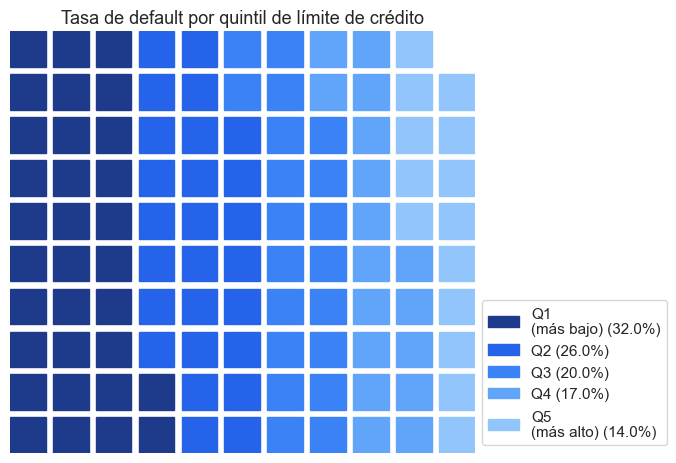

In [47]:
from pywaffle import Waffle
import matplotlib.pyplot as plt

clientes["quintil_limite"] = pd.qcut(
    clientes["LIMIT_BAL"], 
    q=5,
    labels=["Q1\n(más bajo)", "Q2", "Q3", "Q4", "Q5\n(más alto)"]
)

resumen = clientes.groupby("quintil_limite", observed=True)["Default"].apply(
    lambda x: x.astype(int).mean()
) * 100

# convertir a diccionario
data = resumen.round().to_dict()

fig = plt.figure(
    FigureClass=Waffle,
    rows=10,  # 10x10 = 100 cuadritos
    values=data,
    colors=COLORS[:5],
    title={
        'label': 'Tasa de default por quintil de límite de crédito',
        'loc': 'center',
        'fontsize': 13
    },
    labels=[f"{k} ({v:.1f}%)" for k, v in data.items()],
    legend={'loc': 'lower left', 'bbox_to_anchor': (1, 0)}
)

plt.show()

¿Qué grupo etario presenta mayor riesgo de incumplimiento?

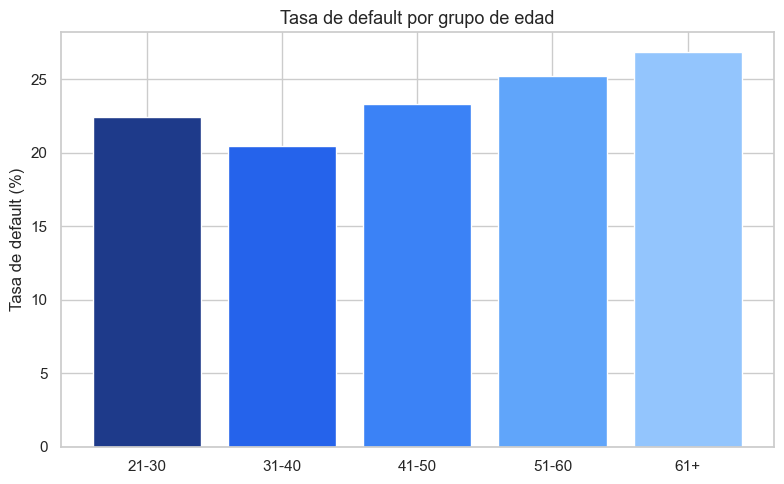

In [29]:
clientes["AGE_group"] = pd.cut(clientes["AGE"], bins=[20, 30, 40, 50, 60, 80],
                               labels=["21-30", "31-40", "41-50", "51-60", "61+"])
tasa = clientes.groupby("AGE_group", observed=True)["Default"].apply(
    lambda x: x.astype(int).mean()) * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(tasa.index, tasa.values, color=COLORS[:len(tasa)])
ax.set_ylabel("Tasa de default (%)")
ax.set_title("Tasa de default por grupo de edad", fontsize=13)
plt.tight_layout()
plt.show()


#### **Gráficos para dashboard: aprobación de crédito**

#### **Perfil del solicitante**

¿Cómo se distribuyen los solicitantes por propósito del préstamo?

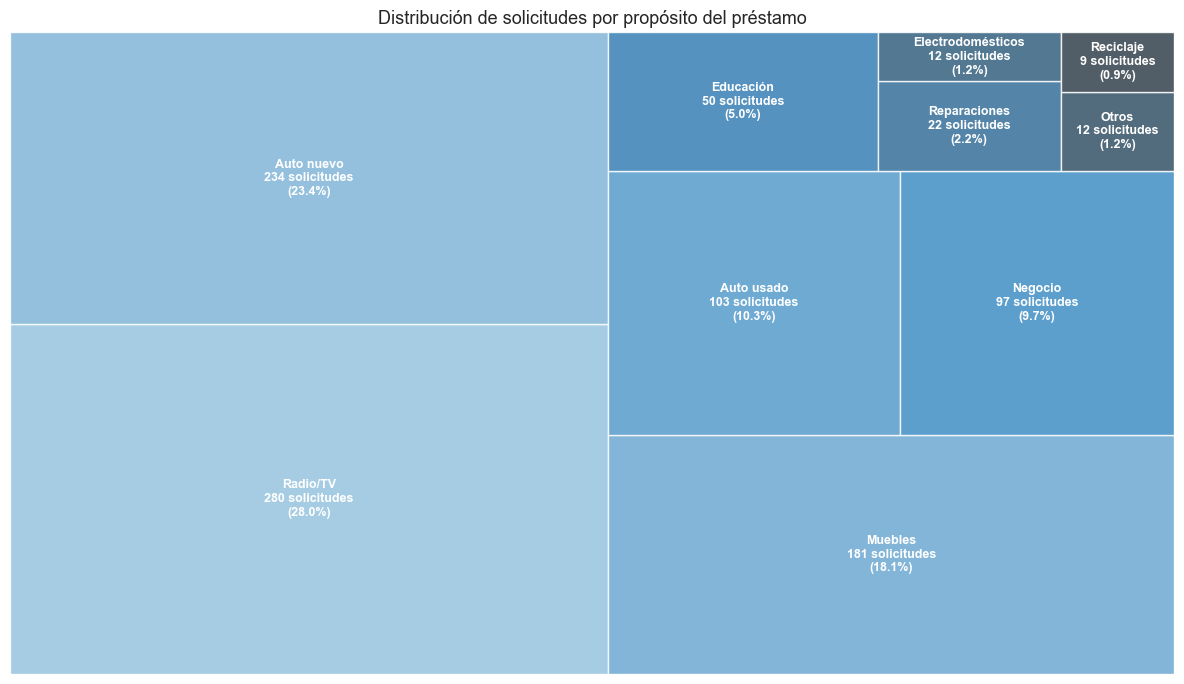

In [30]:
purpose_map = {
    "A40": "Auto nuevo", "A41": "Auto usado", "A42": "Muebles",
    "A43": "Radio/TV", "A44": "Electrodomésticos", "A45": "Reparaciones",
    "A46": "Educación", "A48": "Reciclaje", "A49": "Negocio", "A410": "Otros"
}

german_path["purpose_label"] = german_path["purpose"].map(purpose_map).fillna(german_path["purpose"])
counts = german_path["purpose_label"].value_counts().sort_values(ascending=False)

etiquetas = [f"{prop}\n{n} solicitudes\n({n/counts.sum()*100:.1f}%)"
             for prop, n in counts.items()]
colores = sns.color_palette("Blues_d", len(counts))

fig, ax = plt.subplots(figsize=(12, 7))
squarify.plot(sizes=counts.values, label=etiquetas, color=colores, alpha=0.85,
             ax=ax, text_kwargs={"fontsize": 9, "color": "white", "fontweight": "bold"})
ax.set_title("Distribución de solicitudes por propósito del préstamo", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()


¿Qué tipo de propiedad y situación de vivienda predomina entre los solicitantes?

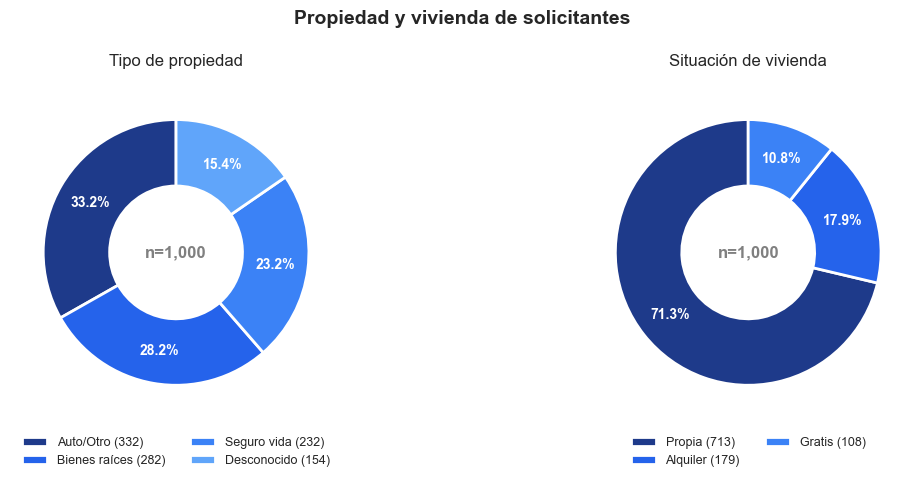

In [31]:
prop_map    = {"A121": "Bienes raíces", "A122": "Seguro vida",
               "A123": "Auto/Otro",     "A124": "Desconocido"}
housing_map = {"A151": "Alquiler", "A152": "Propia", "A153": "Gratis"}

german_path["property_label"] = german_path["property"].map(prop_map).fillna(german_path["property"])
german_path["housing_label"]  = german_path["housing"].map(housing_map).fillna(german_path["housing"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(
    axes,
    ["property_label", "housing_label"],
    ["Tipo de propiedad", "Situación de vivienda"]
):
    counts = german_path[col].value_counts()
    colores = COLORS[:len(counts)]
    wedges, texts, autotexts = ax.pie(
        counts.values, labels=None, colors=colores, autopct="%1.1f%%",
        pctdistance=0.75, startangle=90,
        wedgeprops={"width": 0.5, "edgecolor": "white", "linewidth": 2}
    )
    for autotext in autotexts:
        autotext.set_fontsize(10)
        autotext.set_color("white")
        autotext.set_fontweight("bold")
    ax.text(0, 0, f"n={counts.sum():,}", ha="center", va="center",
            fontsize=12, fontweight="bold", color="gray")
    ax.set_title(title, fontsize=12, pad=15)
    ax.legend(wedges, [f"{cat} ({n})" for cat, n in zip(counts.index, counts.values)],
              loc="lower center", bbox_to_anchor=(0.5, -0.18), ncol=2,
              fontsize=9, frameon=False)

fig.suptitle("Propiedad y vivienda de solicitantes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


¿Cuánto tiempo llevan empleados y cómo se relaciona con el monto solicitado?

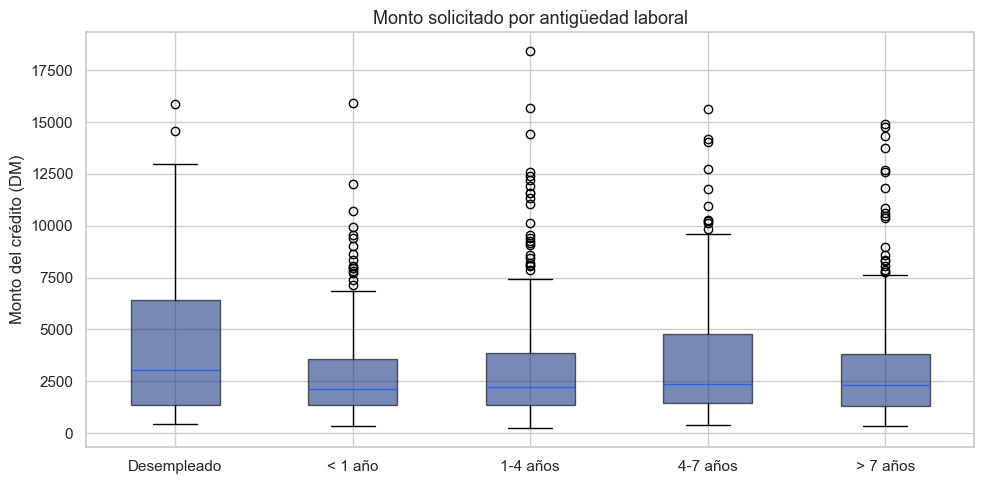

In [32]:
emp_map = {
    "A71": "Desempleado", "A72": "< 1 año",
    "A73": "1-4 años",    "A74": "4-7 años", "A75": "> 7 años"
}
german_path["emp_label"] = german_path["employment_since"].map(emp_map)

fig, ax = plt.subplots(figsize=(10, 5))
orden = ["Desempleado", "< 1 año", "1-4 años", "4-7 años", "> 7 años"]
data  = [german_path[german_path["emp_label"] == cat]["credit_amount"].dropna() for cat in orden]
ax.boxplot(data, labels=orden, patch_artist=True,
           boxprops=dict(facecolor=COLORS[0], alpha=0.6))
ax.set_ylabel("Monto del crédito (DM)")
ax.set_title("Monto solicitado por antigüedad laboral", fontsize=13)
plt.tight_layout()
plt.show()


### **Análisis de crédito**

¿Cuál es el monto promedio y duración media del crédito por propósito?

In [33]:
purpose_map = {
    "A40": "Auto nuevo", "A41": "Auto usado", "A42": "Muebles",
    "A43": "Radio/TV", "A44": "Electrodomésticos", "A45": "Reparaciones",
    "A46": "Educación", "A48": "Reciclaje", "A49": "Negocio", "A410": "Otros"
}
german_path["purpose_label"] = german_path["purpose"].map(purpose_map).fillna(german_path["purpose"])

tabla = german_path.groupby("purpose_label").agg(
    total=("purpose_label", "count"),
    monto_promedio=("credit_amount", "mean"),
    duracion_promedio=("duration_months", "mean")
).round(1).sort_values("monto_promedio", ascending=False)

print(tabla.to_string())


                   total  monto_promedio  duracion_promedio
purpose_label                                              
Otros                 12          8209.3               32.3
Auto usado           103          5370.2               26.1
Negocio               97          4158.0               26.9
Educación             50          3180.4               21.1
Muebles              181          3067.0               19.3
Auto nuevo           234          3063.0               18.5
Reparaciones          22          2728.1               19.1
Radio/TV             280          2487.7               20.0
Electrodomésticos     12          1498.0               16.8
Reciclaje              9          1205.9               11.8


¿Los clientes con cuenta corriente negativa presentan mayor tasa de crédito malo?

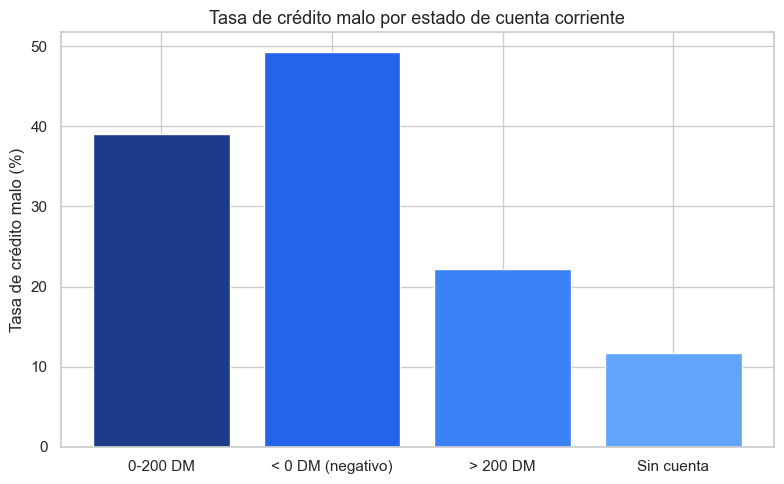

In [34]:
acct_map = {
    "A11": "< 0 DM (negativo)", "A12": "0-200 DM",
    "A13": "> 200 DM",          "A14": "Sin cuenta"
}

german_path["acct_label"] = german_path["status_checking_account"].map(acct_map).fillna(
    german_path["status_checking_account"])
german_path["bad"] = (german_path["target"] == 2).astype(int)

tasa = german_path.groupby("acct_label")["bad"].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(tasa.index, tasa.values, color=COLORS[:len(tasa)])
ax.set_ylabel("Tasa de crédito malo (%)")
ax.set_title("Tasa de crédito malo por estado de cuenta corriente", fontsize=13)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


¿Cómo varía la calificación Good/Bad según el historial crediticio?

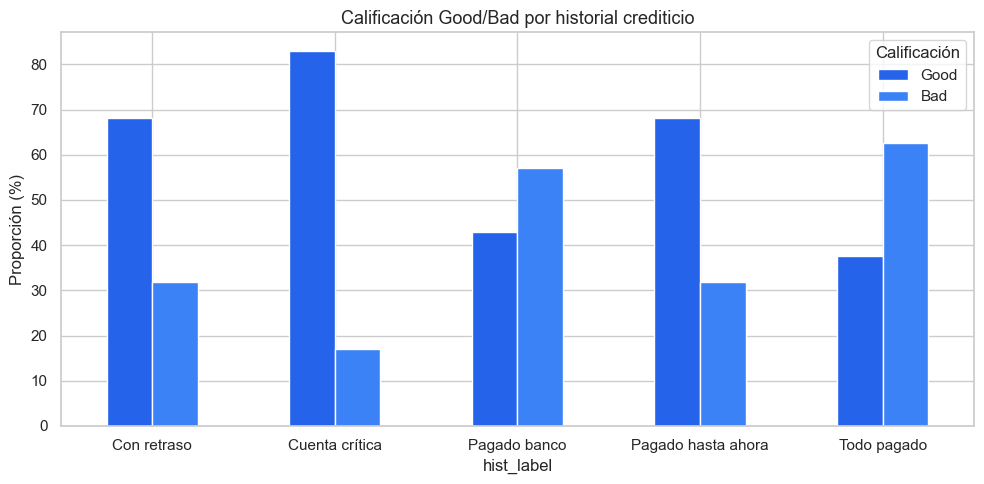

In [35]:
hist_map = {
    "A30": "Todo pagado", "A31": "Pagado banco",
    "A32": "Pagado hasta ahora", "A33": "Con retraso", "A34": "Cuenta crítica"
}
german_path["hist_label"] = german_path["credit_history"].map(hist_map).fillna(
    german_path["credit_history"])

cross = german_path.groupby("hist_label")["bad"].value_counts(normalize=True).unstack() * 100
cross.columns = ["Good", "Bad"]

cross.plot(kind="bar", figsize=(10, 5), color=[COLORS[1], COLORS[2]])
plt.ylabel("Proporción (%)")
plt.title("Calificación Good/Bad por historial crediticio", fontsize=13)
plt.xticks(rotation=0)
plt.legend(title="Calificación")
plt.tight_layout()
plt.show()


¿Cuál es la tasa de aprobación por tipo de empleo?

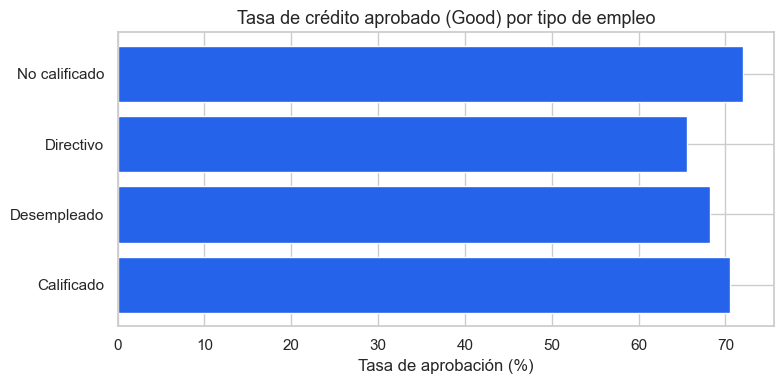

In [36]:
job_map = {
    "A171": "Desempleado", "A172": "No calificado",
    "A173": "Calificado",  "A174": "Directivo"
}
german_path["job_label"] = german_path["job"].map(job_map).fillna(german_path["job"])
german_path["good"]      = (german_path["target"] == 1).astype(int)

tasa = german_path.groupby("job_label")["good"].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(tasa.index, tasa.values, color=COLORS[1])
ax.set_xlabel("Tasa de aprobación (%)")
ax.set_title("Tasa de crédito aprobado (Good) por tipo de empleo", fontsize=13)
plt.tight_layout()
plt.show()


#### **Riesgo en aprobación**

¿Qué variables están más asociadas con un crédito "malo"?

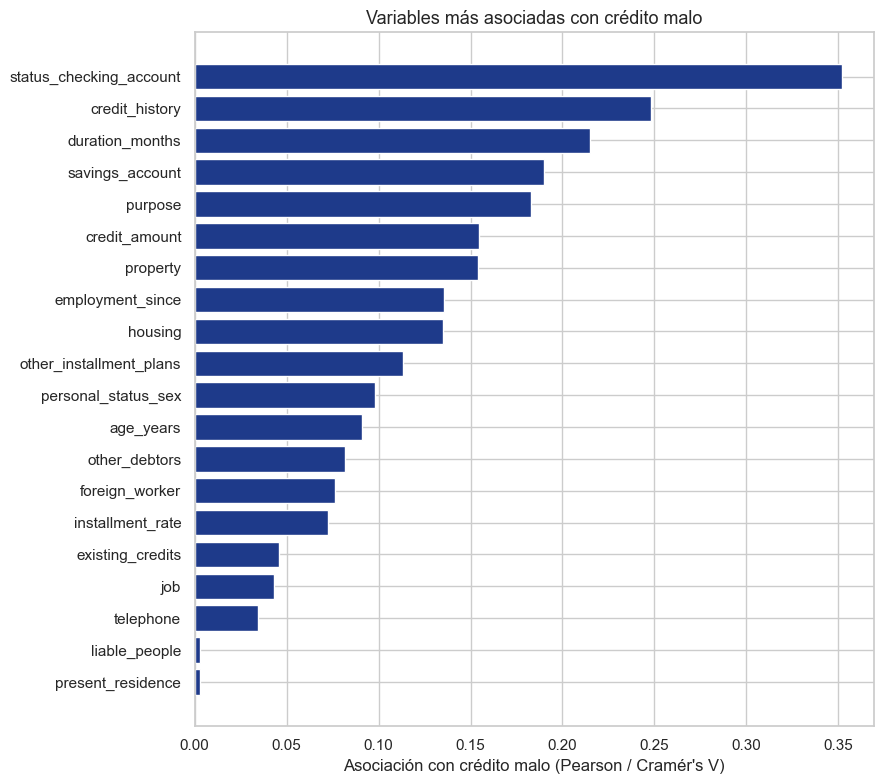

In [37]:
num_cols = ["duration_months", "credit_amount", "installment_rate",
            "present_residence", "age_years", "existing_credits", "liable_people"]
cat_cols = ["status_checking_account", "credit_history", "purpose",
            "savings_account", "employment_since", "personal_status_sex",
            "other_debtors", "property", "other_installment_plans",
            "housing", "job", "telephone", "foreign_worker"]

importancias = {}

for col in num_cols:
    importancias[col] = abs(german_path[col].corr(german_path["bad"]))

def cramers_v(x, y):
    ct   = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n    = ct.sum().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    return np.sqrt(phi2 / min(k - 1, r - 1)) if min(k - 1, r - 1) > 0 else 0

for col in cat_cols:
    importancias[col] = cramers_v(german_path[col].astype(str), german_path["bad"].astype(str))

imp_series = pd.Series(importancias).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(imp_series.index, imp_series.values, color=COLORS[0])
ax.set_xlabel("Asociación con crédito malo (Pearson / Cramér's V)")
ax.set_title("Variables más asociadas con crédito malo", fontsize=13)
plt.tight_layout()
plt.show()


¿El tener garante o co-solicitante reduce la probabilidad de crédito malo?

target           Bad  Good
debtor_label              
Co-solicitante  43.9  56.1
Garante         19.2  80.8
Ninguno         30.0  70.0


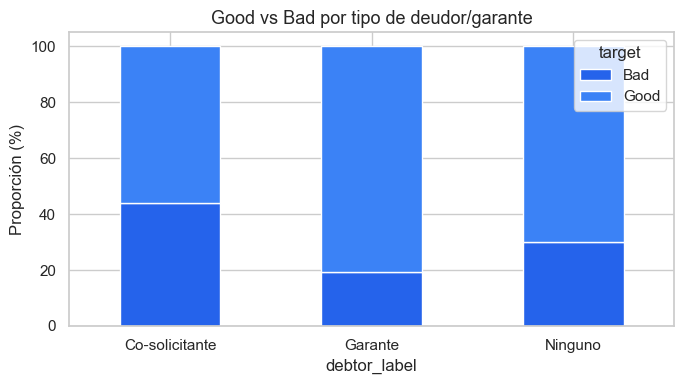

In [38]:
debtor_map = {"A101": "Ninguno", "A102": "Co-solicitante", "A103": "Garante"}
german_path["debtor_label"] = german_path["other_debtors"].map(debtor_map).fillna(
    german_path["other_debtors"])

tabla = pd.crosstab(german_path["debtor_label"], german_path["target"].map({1: "Good", 2: "Bad"}),
                    normalize="index") * 100
print(tabla.round(1).to_string())

tabla.plot(kind="bar", stacked=True, color=[COLORS[1], COLORS[2]], figsize=(7, 4))
plt.ylabel("Proporción (%)")
plt.title("Good vs Bad por tipo de deudor/garante", fontsize=13)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


¿Los trabajadores extranjeros presentan un perfil de riesgo diferenciado?

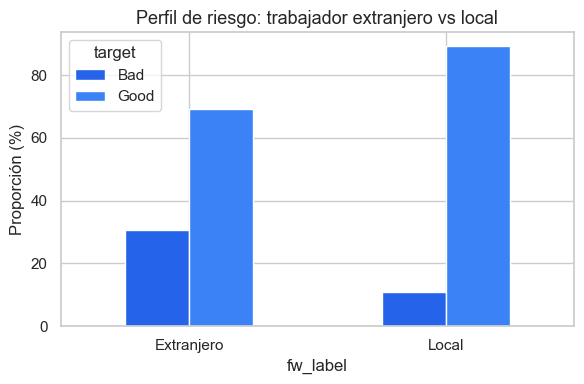

In [39]:
fw_map = {"A201": "Extranjero", "A202": "Local"}
german_path["fw_label"] = german_path["foreign_worker"].map(fw_map).fillna(
    german_path["foreign_worker"])

cross = pd.crosstab(german_path["fw_label"],
                    german_path["target"].map({1: "Good", 2: "Bad"}),
                    normalize="index") * 100

cross.plot(kind="bar", color=[COLORS[1], COLORS[2]], figsize=(6, 4))
plt.ylabel("Proporción (%)")
plt.title("Perfil de riesgo: trabajador extranjero vs local", fontsize=13)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
